# Modelo Supervisado 2: Clasificación de Riesgo Agrícola con **XGBoost**

Este notebook aborda el **Objetivo 3** del proyecto: a partir de variables conocidas *antes* de la
cosecha (estado, municipio, cultivo, modalidad de riego, ciclo agrícola y superficie sembrada),
**clasificar el nivel de riesgo de siniestro** de una siembra en cinco categorías ordinales:

| Código | Nivel de riesgo | Significado |
|:---:|:---|:---|
| 0 | **Sin siniestro** | No se perdió superficie sembrada |
| 1 | **Riesgo bajo** | Se perdió una fracción pequeña del área |
| 2 | **Riesgo medio** | Pérdida intermedia |
| 3 | **Riesgo alto** | Pérdida elevada |
| 4 | **Pérdida crítica** | Pérdida casi total de la siembra |

### ¿Por qué XGBoost?
**XGBoost** (*Extreme Gradient Boosting*) construye árboles de decisión de forma secuencial, donde cada
árbol corrige los errores del anterior mediante *gradient boosting*. Lo elegimos porque:

- Es el estándar de facto para **datos tabulares** heterogéneos y relaciones **no lineales**.
- Incluye **regularización integrada** (`gamma`, `lambda`, `alpha`) que controla el sobreajuste —el eje central de este análisis.
- Maneja el **desbalance de clases** mediante `sample_weight`, sin alterar los datos originales.

> **Reto principal del problema:** el dataset está **severamente desbalanceado** — el ~95 % de los registros
> son "Sin siniestro". Por eso la *accuracy* por sí sola es engañosa y usamos un abanico amplio de métricas
> robustas al desbalance (F1-macro, *balanced accuracy*, Kappa, MCC, AUC-PR).

## Fase 0 · Configuración e importación de librerías

### Cómo leer este notebook

El documento sigue el **flujo natural de un proyecto de modelado**, de principio a fin. En cada fase verás dos tipos de recuadro que te guían:

> **¿Qué buscamos?** — la pregunta o hipótesis que motiva la fase, *antes* de ver resultados.

> **¿Qué obtuvimos?** — la lectura de los números/gráficas reales, *después* del código.

**El recorrido es:**

1. **Fase 1 — Datos:** qué predecimos, con qué variables y por qué partimos el tiempo en pasado/futuro.
2. **Fase 2 — Baseline:** un primer modelo "tal cual" para tener una vara de medir.
3. **Fase 3 — Regularización:** el corazón del análisis; controlar el sobreajuste con `gamma`, `lambda`, `alpha`.
4. **Fase 4 — Modelo final:** el mejor modelo evaluado con una batería completa de métricas.
5. **Fase 5 — Interpretabilidad:** abrir la caja negra (importancia y SHAP) y analizar errores.
6. **Fase 6 — Robustez:** confirmar con validación cruzada que el resultado no fue suerte.

La idea es que, aunque no seas experto/a, al terminar entiendas **qué se hizo, por qué, y qué se logró**.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score, log_loss,
    precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_validate, learning_curve,
)
from sklearn.preprocessing import label_binarize

from src.data_loader import DataLoader
from src.xgboost_model import XGBoostDataPrep

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# sklearn >= 1.6 eliminó `fit_params`. Activamos el ENRUTAMIENTO DE METADATOS
# para poder pasar `sample_weight` a cross_validate / learning_curve vía `params=`.
sklearn.set_config(enable_metadata_routing=True)

# Estilo de gráficas consistente con el resto del proyecto
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)

# Paleta semántica para los 5 niveles de riesgo (verde=seguro ... morado=crítico)
PALETA_RIESGO = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
print('Versiones -> xgboost:', xgb.__version__, '| scikit-learn:', sklearn.__version__)

Versiones -> xgboost: 3.2.0 | scikit-learn: 1.8.0


### Fuente de los datos y su procesamiento

Este modelo **no** procesa los datos: consume el dataset **procesado** que genera el **notebook de EDA** (`notebooks/eda.ipynb`), respetando el flujo del proyecto:

`data/raw/siap_2010_2024.csv`  →  **notebook de EDA**  →  `data/processed/siap_procesado.csv`  →  **modelo**

Todo el **procesamiento** ocurre en el EDA: deriva `proporcion_siniestro` y `nivel_riesgo`, imputa los nulos estructurales, elimina duplicados y exporta el CSV procesado (en utf-8-sig). Aquí el modelo únicamente **lee** ese resultado; si el archivo no existe, primero debe ejecutarse el notebook de EDA.

In [2]:
# === Fuente de datos: dataset PROCESADO por el notebook de EDA ===
# Flujo del proyecto:
#   data/raw/siap_2010_2024.csv  --(notebook de EDA: eda.ipynb)-->  data/processed/siap_procesado.csv
# El procesamiento (derivar proporcion_siniestro y nivel_riesgo, imputar nulos y
# quitar duplicados) ocurre en el EDA, que exporta el CSV procesado. Aqui el
# modelo SOLO consume ese resultado.
RUTA_PROCESADO = Path('..') / 'data' / 'processed' / 'siap_procesado.csv'
if not RUTA_PROCESADO.exists():
    raise FileNotFoundError(
        f'No se encontro {RUTA_PROCESADO}. Ejecuta primero el notebook de EDA '
        '(notebooks/eda.ipynb), que procesa data/raw/siap_2010_2024.csv y exporta el procesado.'
    )

# El procesado se escribe en utf-8-sig (EDAAnalyzer.exportar_dataset_limpio);
# leerlo con el encoding correcto evita el mojibake de 'Perdida critica'.
loader = DataLoader(RUTA_PROCESADO, encoding='utf-8-sig')
df_raw = loader.cargar()

print('Dimensiones del dataset:', df_raw.shape)
# Eliminar los pocos nulos residuales en las columnas base
df_raw = df_raw.dropna(subset=['Sembrada', 'Volumenproduccion']).copy()
print('Tras eliminar nulos residuales:', df_raw.shape)
df_raw[['Anio', 'Idestado', 'Idcultivo', 'Sembrada', 'nivel_riesgo']].head()

[DataLoader] Cargando siap_procesado.csv ...


[DataLoader] 541829 filas , 26 columnas cargadas.
Dimensiones del dataset: (541829, 26)
Tras eliminar nulos residuales: (541826, 26)


,Anio,Idestado,Idcultivo,Sembrada,nivel_riesgo
0,2010,1,5490000,847.0,Sin siniestro
1,2010,1,9090000,370.0,Sin siniestro
2,2010,1,15050000,289.0,Sin siniestro
3,2010,1,5740000,4.0,Sin siniestro
4,2010,1,5940000,15.0,Sin siniestro


## Fase 1 · Ingeniería de *features* y preparación de los datos

La preparación está encapsulada en `src/xgboost_model.py` (clase `XGBoostDataPrep`). Resumen de lo que hace:

1. **Ingeniería de variables:**
   - `log_sembrada = log1p(Sembrada)` → comprime la fuerte asimetría de la superficie sembrada (muchas parcelas chicas, pocas enormes).
   - `interaccion_mod_ciclo = Idmodalidad × Idciclo` → captura el efecto combinado de regar/no regar según el ciclo.
2. **Codificación:** *Label Encoding* para `Idestado`, `Idmunicipio`, `Idcultivo` (alta cardinalidad). `Idciclo` e `Idmodalidad` ya son numéricas.
3. **Variable objetivo:** `nivel_riesgo` → entero ordinal 0–4.

> **Prevención de fuga de información (*data leakage*):** se **excluyen** `Cosechada`, `Siniestrada`,
> `Volumenproduccion`, `Rendimiento`, `Precio`, `Valorproduccion` y `proporcion_siniestro`, porque son
> resultados que solo se conocen *después* de la cosecha. El modelo solo usa información disponible
> **antes** de sembrar/durante el ciclo.

### *Split* temporal (no aleatorio)
Para simular el uso real —entrenar con el pasado para predecir el futuro— partimos por año:

| Conjunto | Años | Uso |
|:--|:--|:--|
| **Entrenamiento** | 2010–2020 | Ajustar el modelo |
| **Validación** | 2021–2022 | Elegir hiperparámetros |
| **Test** | 2023–2024 | Evaluación final e imparcial (datos nunca vistos) |

In [3]:
prep = XGBoostDataPrep(df_raw)
df_processed = prep.preprocess()

(X_train, y_train), (X_val, y_val), (X_test, y_test) = prep.temporal_split()

# Renombrar columnas a nombres legibles para que TODAS las gráficas se entiendan
nombres = prep.FEATURES_LEGIBLES
X_train = X_train.rename(columns=nombres)
X_val   = X_val.rename(columns=nombres)
X_test  = X_test.rename(columns=nombres)

target_names = list(prep.riesgo_map.keys())   # ['Sin siniestro', ..., 'Pérdida crítica']

# Pesos por clase para compensar el desbalance (solo en entrenamiento)
sample_weights = prep.get_sample_weights(y_train)

Iniciando preprocesamiento de datos para XGBoost...


Preprocesamiento completado.
  Filas: 541,826
  Distribución target: {0: np.int64(515009), 1: np.int64(7072), 2: np.int64(8475), 3: np.int64(5197), 4: np.int64(6073)}

Features utilizadas (8): ['Anio', 'Idestado_encoded', 'Idmunicipio_encoded', 'Idciclo', 'Idmodalidad', 'Idcultivo_encoded', 'log_sembrada', 'interaccion_mod_ciclo']
Entrenamiento (2010-2020): 395,273 registros (73.0%)
Validación    (2021-2022): 66,293 registros (12.2%)
Test          (2023-2024): 80,260 registros (14.8%)

Pesos de clase calculados (balanced):
  Clase 0: 0.2120
  Clase 1: 13.0003
  Clase 2: 11.5560
  Clase 3: 18.5792
  Clase 4: 15.2851


### El desbalance de clases, visto de frente
Antes de modelar, visualizamos *por qué* este problema es difícil. La siguiente gráfica muestra cuántos
registros hay de cada nivel de riesgo: la clase "Sin siniestro" domina de forma abrumadora. Un modelo
ingenuo que prediga siempre "Sin siniestro" acertaría ~95 % de las veces **sin aprender nada útil** — de
ahí que necesitemos pesos por clase y métricas que premien detectar las clases minoritarias.

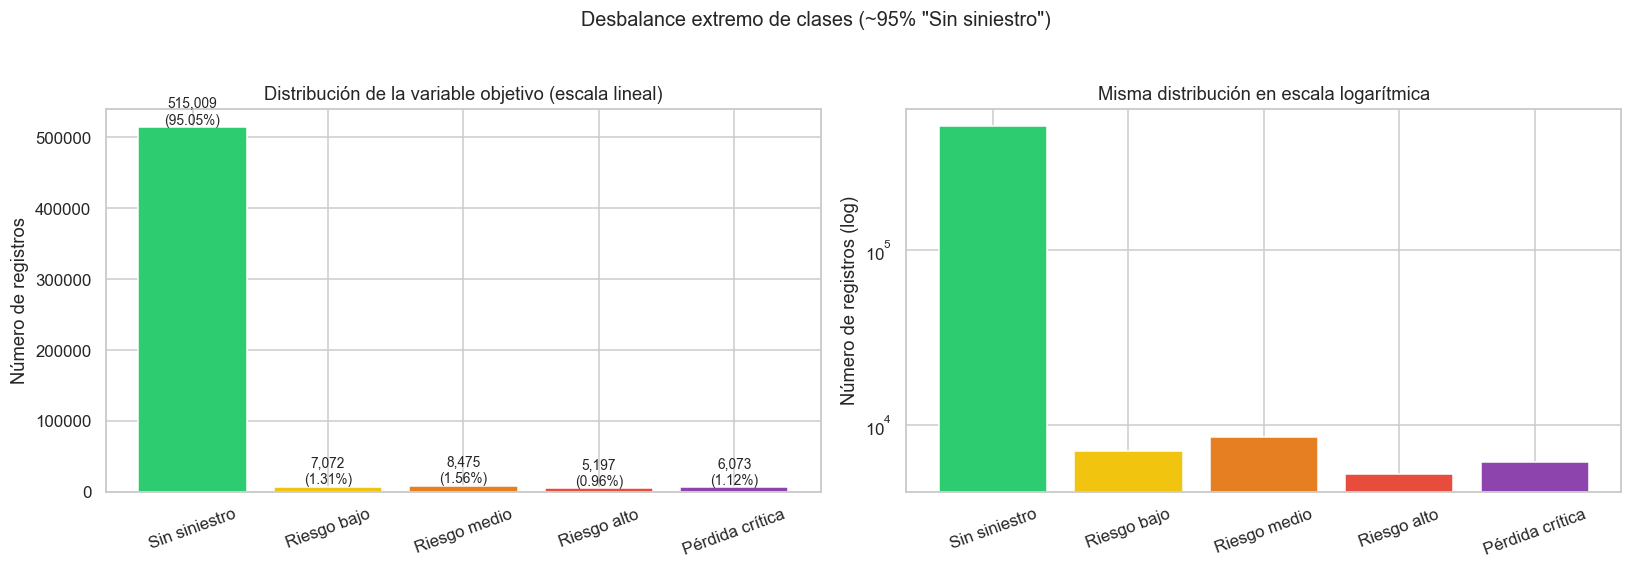

In [4]:
dist = pd.Series(prep.df['target']).value_counts().sort_index()
dist.index = target_names

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar(dist.index, dist.values, color=PALETA_RIESGO, edgecolor='white')
axes[0].set_title('Distribución de la variable objetivo (escala lineal)', fontsize=12)
axes[0].set_ylabel('Número de registros')
for b, v in zip(bars, dist.values):
    axes[0].text(b.get_x()+b.get_width()/2, v, f'{v:,}\n({v/dist.sum()*100:.2f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(dist.index, dist.values, color=PALETA_RIESGO, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Misma distribución en escala logarítmica', fontsize=12)
axes[1].set_ylabel('Número de registros (log)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Desbalance extremo de clases (~95% "Sin siniestro")', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('figuras/distribucion_clases_target.png', dpi=150, bbox_inches='tight')
plt.show()

> **¿Qué obtuvimos?** La gráfica confirma el reto de raíz: de los **541 826** registros, **515 009 (≈95.0 %)** son *"Sin siniestro"*. Las cuatro clases de riesgo juntas apenas suman ~5 %, y la más rara —*Riesgo alto*— es apenas el **0.96 %**. Esto tiene dos consecuencias que marcan todo lo que sigue:

> 1. **La *accuracy* es engañosa:** un modelo que dijera siempre "Sin siniestro" acertaría el 95 % sin aprender nada. Por eso priorizamos **F1-macro** y **balanced accuracy**.
> 2. **Necesitamos `sample_weight`:** los pesos calculados van de **0.21** (clase mayoritaria) hasta **18.6** (clase rara). Así, equivocarse en una siembra de riesgo "pesa" ~88× más que en una sin siniestro, obligando al modelo a prestarles atención.

## Fase 2 · Modelo *baseline* (XGBoost sin optimizar)

Entrenamos un primer XGBoost con hiperparámetros por defecto. Su único propósito es servir de **línea
base de referencia**: cualquier mejora posterior (regularización, *tuning*) se medirá contra él.

- `objective='multi:softprob'`: clasificación multiclase devolviendo **probabilidades** por clase.
- `eval_metric=['mlogloss','merror']`: registramos el error en train y validación en cada iteración
  para poder dibujar la **curva de entrenamiento**.
- `sample_weight`: aplica los pesos por clase para que el modelo no ignore a las minoritarias.

In [5]:
xgb_baseline = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric=['mlogloss', 'merror'],
    n_estimators=300,
    tree_method='hist',
    random_state=RANDOM_STATE,
)

print('Entrenando modelo baseline...')
xgb_baseline.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
print('Modelo baseline entrenado.')

Entrenando modelo baseline...


Modelo baseline entrenado.


### Curva de entrenamiento (¿cuántos árboles necesitamos?)
La curva de entrenamiento muestra cómo evoluciona el error a medida que se agregan árboles (`n_estimators`).
Comparando **train** vs **validación** detectamos sobreajuste: si el error de train sigue bajando pero el
de validación se estanca o sube, el modelo está memorizando ruido. Es la motivación directa de la Fase 3.

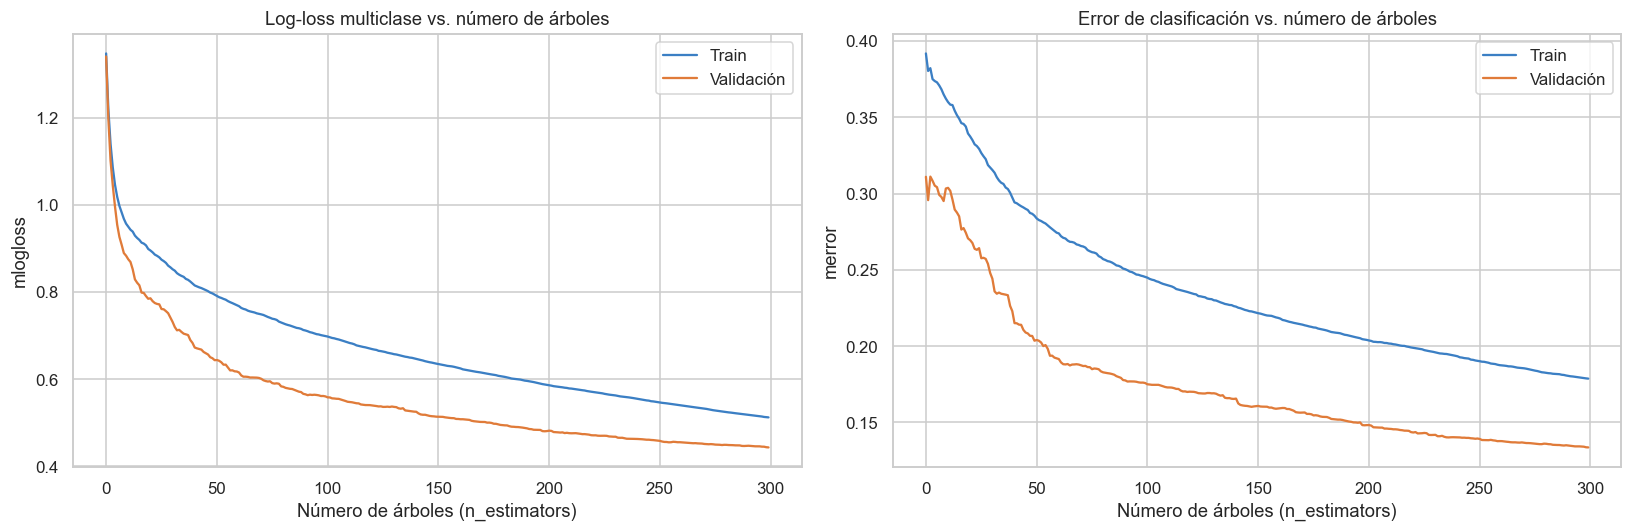

In [6]:
results = xgb_baseline.evals_result()
epochs = range(len(results['validation_0']['mlogloss']))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(epochs, results['validation_0']['mlogloss'], label='Train', color='#3b7fc4')
axes[0].plot(epochs, results['validation_1']['mlogloss'], label='Validación', color='#e07b39')
axes[0].set_title('Log-loss multiclase vs. número de árboles', fontsize=12)
axes[0].set_xlabel('Número de árboles (n_estimators)'); axes[0].set_ylabel('mlogloss'); axes[0].legend()

axes[1].plot(epochs, results['validation_0']['merror'], label='Train', color='#3b7fc4')
axes[1].plot(epochs, results['validation_1']['merror'], label='Validación', color='#e07b39')
axes[1].set_title('Error de clasificación vs. número de árboles', fontsize=12)
axes[1].set_xlabel('Número de árboles (n_estimators)'); axes[1].set_ylabel('merror'); axes[1].legend()

plt.tight_layout()
plt.savefig('figuras/curva_entrenamiento_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluación del *baseline* en validación
El **reporte de clasificación** desglosa, por clase, tres métricas fundamentales:

- **Precision** = de todo lo que el modelo predijo como clase *X*, ¿qué fracción era realmente *X*? (penaliza falsos positivos).
- **Recall** (sensibilidad) = de todos los casos que **eran** clase *X*, ¿cuántos detectó? (penaliza falsos negativos).
- **F1-score** = media armónica de *precision* y *recall*; resume ambas en un solo número.

El **F1-macro** (promedio simple entre clases) es nuestra métrica guía porque trata a todas las clases por
igual, sin dejar que la clase mayoritaria domine.

In [7]:
y_val_pred = xgb_baseline.predict(X_val)

print('=== Reporte de Clasificación · Baseline (Validación 2021-2022) ===')
print(classification_report(y_val, y_val_pred, labels=list(range(5)),
                            target_names=target_names, zero_division=0))

f1_macro_base = f1_score(y_val, y_val_pred, average='macro')
acc_base = accuracy_score(y_val, y_val_pred)
print(f'F1-Score (Macro): {f1_macro_base:.4f}')
print(f'Accuracy:         {acc_base:.4f}')

=== Reporte de Clasificación · Baseline (Validación 2021-2022) ===
                 precision    recall  f1-score   support

  Sin siniestro       0.99      0.88      0.93     64843
    Riesgo bajo       0.06      0.32      0.10       465
   Riesgo medio       0.03      0.17      0.06       538
    Riesgo alto       0.04      0.28      0.07       288
Pérdida crítica       0.01      0.09      0.02       159

       accuracy                           0.87     66293
      macro avg       0.23      0.35      0.24     66293
   weighted avg       0.97      0.87      0.91     66293

F1-Score (Macro): 0.2356
Accuracy:         0.8664


> **¿Qué obtuvimos?** El baseline alcanza **accuracy 0.866** pero un **F1-macro de solo 0.236**. Esa brecha es exactamente el síntoma del desbalance: acierta casi siempre en "Sin siniestro" (*recall* 0.88) pero **fracasa en las clases de riesgo**. Por ejemplo, en *Pérdida crítica* logra *recall* 0.09 y *precision* 0.01: detecta pocas y, de las que marca, casi todas son falsas alarmas. En otras palabras, **el modelo "crudo" sí intenta marcar riesgos, pero lo hace muy mal**. Este 0.236 es la vara que tendremos que superar.

### Matriz de confusión del *baseline*
La **matriz de confusión** cruza el valor real (filas) contra la predicción (columnas). La diagonal son los
aciertos; fuera de la diagonal están los errores. Nos permite ver *qué* clases se confunden entre sí
(p. ej. si "Riesgo medio" se confunde con "Riesgo alto", que son adyacentes).

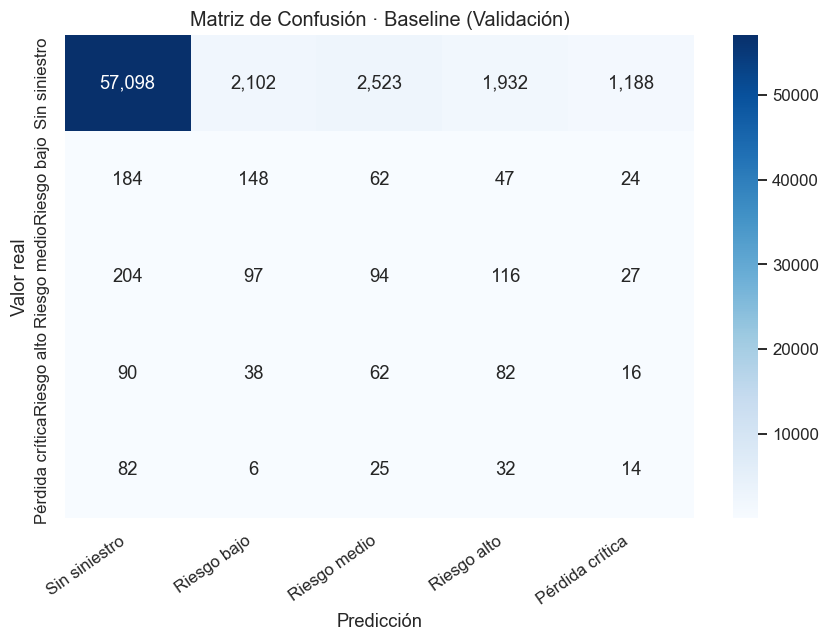

In [8]:
cm_base = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt=',d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_title('Matriz de Confusión · Baseline (Validación)', fontsize=13)
ax.set_ylabel('Valor real'); ax.set_xlabel('Predicción')
plt.xticks(rotation=35, ha='right'); plt.tight_layout()
plt.savefig('figuras/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

> **¿Qué obtuvimos?** Fuera de la diagonal vemos que los errores **no son aleatorios**: el modelo tiende a confundir niveles **adyacentes** (medio↔alto, bajo↔medio), lo cual es esperable y "menos grave" en un problema ordinal. El problema serio es la dispersión de las clases minoritarias hacia "Sin siniestro". Esto motiva la **Fase 3**: regularizar para que el modelo generalice en vez de reaccionar al ruido.

## Fase 3 · Regularización: `gamma`, `lambda` (L2) y `alpha` (L1)

Esta es la **sección central** del análisis. La regularización combate el sobreajuste penalizando la
complejidad del modelo. XGBoost ofrece tres palancas, que estudiamos primero **una por una** (para aislar
su efecto) y luego **en conjunto**.

La función objetivo de XGBoost es **Pérdida + Regularización**:

$$\mathcal{L} = \sum_i l(\hat{y}_i, y_i) \;+\; \sum_k \Big[ \gamma\, T_k + \tfrac{1}{2}\lambda \lVert w_k \rVert^2 + \alpha \lVert w_k \rVert_1 \Big]$$

donde $T_k$ es el número de hojas del árbol $k$ y $w_k$ sus pesos. La ganancia de un *split* es:

$$\text{Ganancia} = \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} - \gamma$$

| Hiperparámetro | Qué penaliza | Efecto | Default |
|:--|:--|:--|:--:|
| **`gamma`** ($\gamma$) | Ganancia mínima para abrir un *split* | Poda ramas poco útiles → árboles más simples | 0 |
| **`lambda`** ($\lambda$, L2) | Magnitud **al cuadrado** de los pesos | Suaviza predicciones, reduce varianza | 1 |
| **`alpha`** ($\alpha$, L1) | Magnitud **absoluta** de los pesos | Lleva pesos a 0 → *sparsity* | 0 |

### Experimento 1 — Efecto individual de `gamma`

In [9]:
def evaluar(model):
    model.fit(X_train, y_train, sample_weight=sample_weights,
              eval_set=[(X_val, y_val)], verbose=False)
    yp = model.predict(X_val); pp = model.predict_proba(X_val)
    return (f1_score(y_val, yp, average='macro'),
            accuracy_score(y_val, yp),
            log_loss(y_val, pp, labels=list(range(5))))

def base_model(**kw):
    p = dict(objective='multi:softprob', n_estimators=200, tree_method='hist',
             random_state=RANDOM_STATE)
    p.update(kw); return xgb.XGBClassifier(**p)

gamma_values = [0, 0.1, 0.5, 1, 2, 5, 10]
gamma_results = []
for g in gamma_values:
    f1, acc, ll = evaluar(base_model(gamma=g, reg_lambda=1, reg_alpha=0))
    gamma_results.append({'gamma': g, 'f1_macro': f1, 'accuracy': acc, 'logloss': ll})
    print(f'  gamma={g:>5} -> F1-macro={f1:.4f}  logloss={ll:.4f}')

df_gamma = pd.DataFrame(gamma_results)
best_gamma = df_gamma.loc[df_gamma['f1_macro'].idxmax(), 'gamma']
print('\nMejor gamma:', best_gamma)
df_gamma

  gamma=    0 -> F1-macro=0.2322  logloss=0.4806


  gamma=  0.1 -> F1-macro=0.2330  logloss=0.4774


  gamma=  0.5 -> F1-macro=0.2290  logloss=0.5125


  gamma=    1 -> F1-macro=0.2269  logloss=0.5457


  gamma=    2 -> F1-macro=0.2236  logloss=0.5815


  gamma=    5 -> F1-macro=0.2168  logloss=0.6580


  gamma=   10 -> F1-macro=0.2121  logloss=0.7209

Mejor gamma: 0.1


,gamma,f1_macro,accuracy,logloss
0,0.0,0.232248,0.851779,0.480635
1,0.1,0.232996,0.855852,0.477438
2,0.5,0.228994,0.838957,0.512470
3,1.0,0.226895,0.827448,0.545727
4,2.0,0.223565,0.819951,0.581539
5,5.0,0.216773,0.792587,0.658018
6,10.0,0.212148,0.769206,0.720944


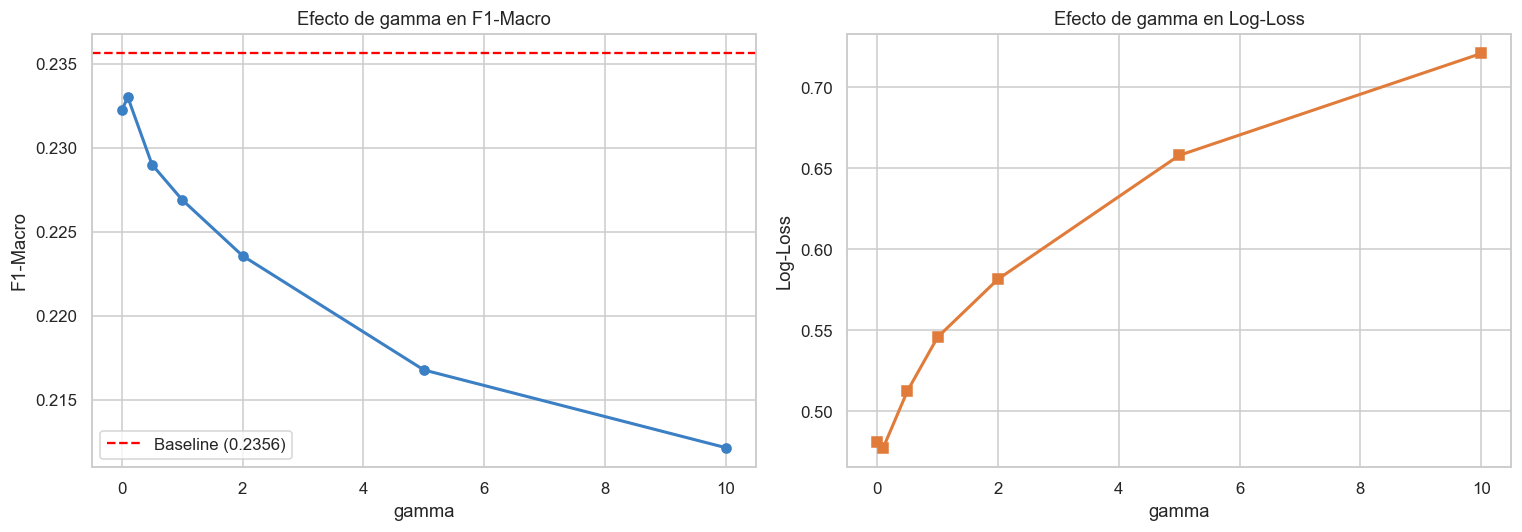

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_gamma['gamma'], df_gamma['f1_macro'], marker='o', color='#3b7fc4', lw=2)
axes[0].axhline(f1_macro_base, color='red', ls='--', label=f'Baseline ({f1_macro_base:.4f})')
axes[0].set_title('Efecto de gamma en F1-Macro'); axes[0].set_xlabel('gamma'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
axes[1].plot(df_gamma['gamma'], df_gamma['logloss'], marker='s', color='#e07b39', lw=2)
axes[1].set_title('Efecto de gamma en Log-Loss'); axes[1].set_xlabel('gamma'); axes[1].set_ylabel('Log-Loss')
plt.tight_layout(); plt.savefig('figuras/exp1_gamma.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** El mejor `gamma` es **0.1** (F1-macro 0.233), apenas por encima del valor por defecto. A partir de ahí, subir `gamma` **degrada todo**: con `gamma=10` el F1 cae a 0.212 y el *log-loss* casi se duplica (0.48 → 0.72). Lectura: en estos datos **podar agresivamente los *splits* hace más daño que bien**; basta una poda suave.

### Experimento 2 — Efecto individual de `lambda` (L2)

**¿Qué buscamos?** Fijamos `gamma` en su mejor valor y barremos `lambda` (penalización **L2**, sobre el *cuadrado* de los pesos de las hojas). Esperamos ver una curva en forma de **U invertida**: poca regularización deja sobreajustar; demasiada aplana el modelo y empeora. El óptimo está en el medio.

In [11]:
lambda_values = [0, 0.01, 0.1, 1, 5, 10, 50, 100]
lambda_results = []
for l in lambda_values:
    f1, acc, ll = evaluar(base_model(gamma=best_gamma, reg_lambda=l, reg_alpha=0))
    lambda_results.append({'reg_lambda': l, 'f1_macro': f1, 'accuracy': acc, 'logloss': ll})
    print(f'  lambda={l:>6} -> F1-macro={f1:.4f}  logloss={ll:.4f}')

df_lambda = pd.DataFrame(lambda_results)
best_lambda = df_lambda.loc[df_lambda['f1_macro'].idxmax(), 'reg_lambda']
print('\nMejor lambda:', best_lambda)
df_lambda

  lambda=     0 -> F1-macro=0.2321  logloss=0.4808


  lambda=  0.01 -> F1-macro=0.2346  logloss=0.4763


  lambda=   0.1 -> F1-macro=0.2326  logloss=0.4785


  lambda=     1 -> F1-macro=0.2330  logloss=0.4774


  lambda=     5 -> F1-macro=0.2313  logloss=0.4947


  lambda=    10 -> F1-macro=0.2274  logloss=0.5180


  lambda=    50 -> F1-macro=0.2296  logloss=0.5479


  lambda=   100 -> F1-macro=0.2259  logloss=0.5706

Mejor lambda: 0.01


,reg_lambda,f1_macro,accuracy,logloss
0,0.00,0.232118,0.854540,0.480751
1,0.01,0.234555,0.858552,0.476281
2,0.10,0.232577,0.855053,0.478546
3,1.00,0.232996,0.855852,0.477438
4,5.00,0.231281,0.846831,0.494656
5,10.00,0.227438,0.837223,0.518043
6,50.00,0.229558,0.828549,0.547859
7,100.00,0.225857,0.818367,0.570614


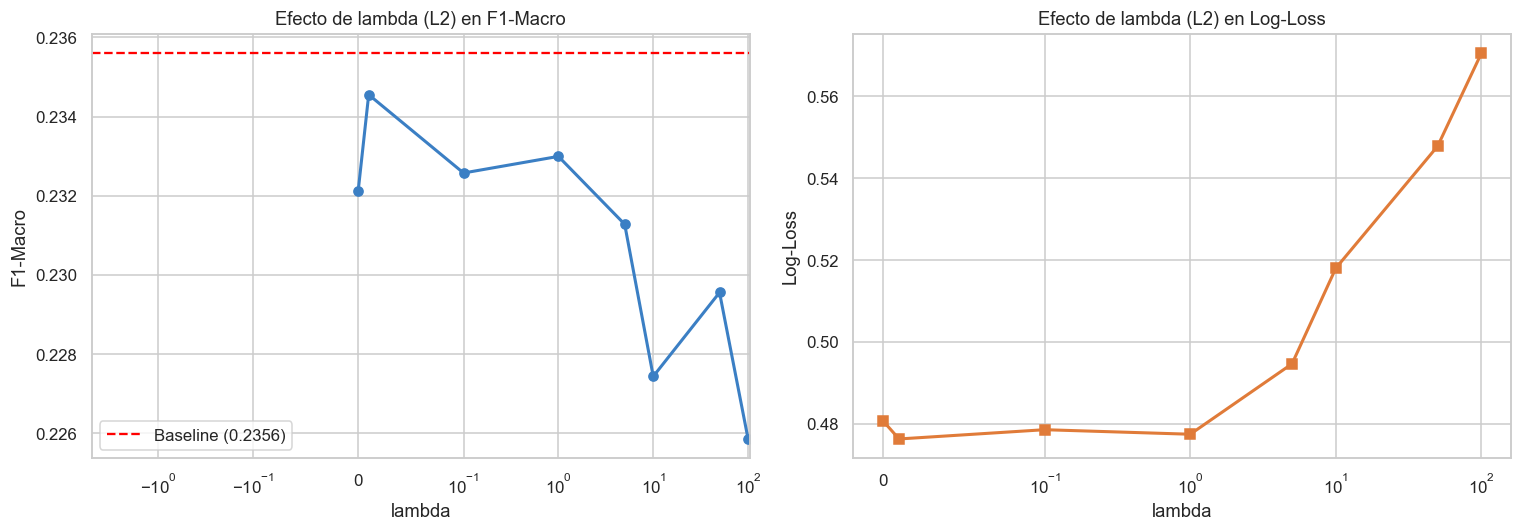

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_lambda['reg_lambda'], df_lambda['f1_macro'], marker='o', color='#3b7fc4', lw=2)
axes[0].axhline(f1_macro_base, color='red', ls='--', label=f'Baseline ({f1_macro_base:.4f})')
axes[0].set_xscale('symlog', linthresh=0.1)
axes[0].set_title('Efecto de lambda (L2) en F1-Macro'); axes[0].set_xlabel('lambda'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
axes[1].plot(df_lambda['reg_lambda'], df_lambda['logloss'], marker='s', color='#e07b39', lw=2)
axes[1].set_xscale('symlog', linthresh=0.1)
axes[1].set_title('Efecto de lambda (L2) en Log-Loss'); axes[1].set_xlabel('lambda'); axes[1].set_ylabel('Log-Loss')
plt.tight_layout(); plt.savefig('figuras/exp2_lambda.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** Aparece la **U invertida** esperada: el óptimo es `lambda=0.01` (F1-macro 0.235, el mejor *log-loss* del barrido), y al pasar de `lambda=10` el desempeño se deteriora de forma sostenida. La mejora respecto al *default* es pequeña, lo que adelanta una idea clave: **ajustar un solo regularizador no mueve mucho la aguja**.

### Experimento 3 — Efecto individual de `alpha` (L1)

**¿Qué buscamos?** Igual que antes, pero con `alpha` (penalización **L1**, sobre el *valor absoluto* de los pesos). A diferencia de L2, L1 puede llevar pesos **exactamente a 0**, eliminando hojas poco útiles. Buscamos el valor que maximice el F1-macro sin disparar el *log-loss*.

In [13]:
alpha_values = [0, 0.001, 0.01, 0.1, 1, 5, 10, 50]
alpha_results = []
for a in alpha_values:
    f1, acc, ll = evaluar(base_model(gamma=best_gamma, reg_lambda=best_lambda, reg_alpha=a))
    alpha_results.append({'reg_alpha': a, 'f1_macro': f1, 'accuracy': acc, 'logloss': ll})
    print(f'  alpha={a:>6} -> F1-macro={f1:.4f}  logloss={ll:.4f}')

df_alpha = pd.DataFrame(alpha_results)
best_alpha = df_alpha.loc[df_alpha['f1_macro'].idxmax(), 'reg_alpha']
print('\nMejor alpha:', best_alpha)
df_alpha

  alpha=     0 -> F1-macro=0.2346  logloss=0.4763


  alpha= 0.001 -> F1-macro=0.2321  logloss=0.4763


  alpha=  0.01 -> F1-macro=0.2351  logloss=0.4743


  alpha=   0.1 -> F1-macro=0.2348  logloss=0.4777


  alpha=     1 -> F1-macro=0.2325  logloss=0.4878


  alpha=     5 -> F1-macro=0.2305  logloss=0.5105


  alpha=    10 -> F1-macro=0.2306  logloss=0.5221


  alpha=    50 -> F1-macro=0.2218  logloss=0.6185

Mejor alpha: 0.01


,reg_alpha,f1_macro,accuracy,logloss
0,0.000,0.234555,0.858552,0.476281
1,0.001,0.232063,0.853801,0.476294
2,0.010,0.235088,0.858024,0.474284
3,0.100,0.234779,0.856259,0.477675
4,1.000,0.232528,0.849894,0.487800
5,5.000,0.230539,0.842608,0.510461
6,10.000,0.230571,0.840496,0.522076
7,50.000,0.221827,0.802770,0.618509


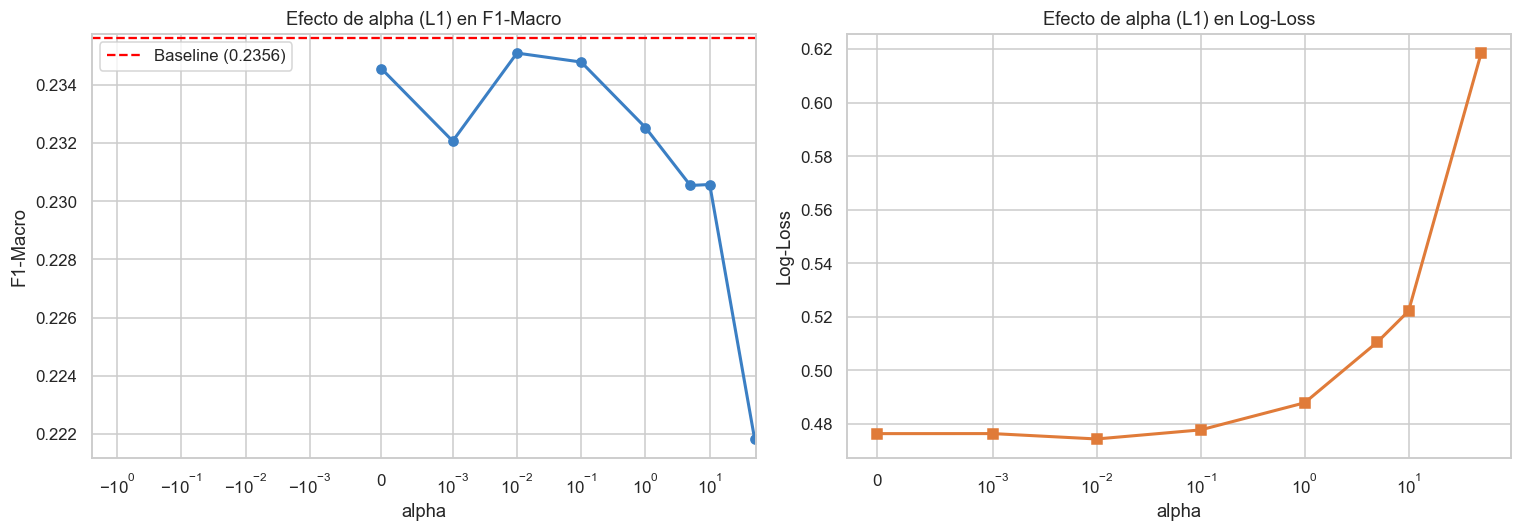

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_alpha['reg_alpha'], df_alpha['f1_macro'], marker='o', color='#3b7fc4', lw=2)
axes[0].axhline(f1_macro_base, color='red', ls='--', label=f'Baseline ({f1_macro_base:.4f})')
axes[0].set_xscale('symlog', linthresh=0.001)
axes[0].set_title('Efecto de alpha (L1) en F1-Macro'); axes[0].set_xlabel('alpha'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
axes[1].plot(df_alpha['reg_alpha'], df_alpha['logloss'], marker='s', color='#e07b39', lw=2)
axes[1].set_xscale('symlog', linthresh=0.001)
axes[1].set_title('Efecto de alpha (L1) en Log-Loss'); axes[1].set_xlabel('alpha'); axes[1].set_ylabel('Log-Loss')
plt.tight_layout(); plt.savefig('figuras/exp3_alpha.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** El mejor `alpha` es **0.01** (F1-macro 0.235) y, como con `lambda`, la ganancia individual es marginal. Confirmamos el patrón de los tres experimentos: **afinar `gamma`, `lambda` o `alpha` por separado deja el F1-macro estancado alrededor de 0.23–0.24.** La pregunta natural es: ¿y si los combinamos?

### Experimento 4 — Búsqueda conjunta con `RandomizedSearchCV`
Los efectos individuales ignoran las **interacciones** entre hiperparámetros. Aquí exploramos
combinaciones al azar de los tres regularizadores junto con otros parámetros clave (`max_depth`,
`learning_rate`, etc.), validando cada candidato con **validación cruzada estratificada** (3 *folds*)
y optimizando el **F1-macro**.

> *Nota técnica:* como sklearn ≥ 1.6 enruta `sample_weight` por metadatos, marcamos el estimador con
> `.set_fit_request(sample_weight=True)` para que la búsqueda lo aplique correctamente en cada *fold*.

In [15]:
param_dist = {
    'gamma':            [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda':       [0.01, 0.1, 1, 5, 10, 50],
    'reg_alpha':        [0, 0.01, 0.1, 1, 5, 10],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'n_estimators':     [100, 200, 300],
    'min_child_weight': [1, 3, 5, 10],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

xgb_search = xgb.XGBClassifier(objective='multi:softprob', tree_method='hist',
                               random_state=RANDOM_STATE)
xgb_search.set_fit_request(sample_weight=True)   # enrutamiento de metadatos (sklearn >=1.6)

random_search = RandomizedSearchCV(
    estimator=xgb_search, param_distributions=param_dist,
    n_iter=40, scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, return_train_score=True, verbose=1,
)

print('Buscando hiperparámetros (40 combinaciones x 3 folds)...')
random_search.fit(X_train, y_train, sample_weight=sample_weights.to_numpy())

print(f'\nMejor F1-Macro (CV): {random_search.best_score_:.4f}')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')

Buscando hiperparámetros (40 combinaciones x 3 folds)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits



Mejor F1-Macro (CV): 0.3457
  subsample: 0.7
  reg_lambda: 0.01
  reg_alpha: 0.1
  n_estimators: 300
  min_child_weight: 10
  max_depth: 9
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 0.8


In [16]:
cv_results = pd.DataFrame(random_search.cv_results_)
cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_gamma', 'param_reg_lambda', 'param_reg_alpha',
        'param_max_depth', 'param_learning_rate', 'param_n_estimators']
top10 = cv_results[cols].sort_values('rank_test_score').head(10).reset_index(drop=True)
print('=== Top 10 configuraciones de la búsqueda ===')
top10

=== Top 10 configuraciones de la búsqueda ===


,rank_test_score,mean_test_score,std_test_score,param_gamma,param_reg_lambda,param_reg_alpha,param_max_depth,param_learning_rate,param_n_estimators
0,1,0.345704,0.000673,0.1,0.01,0.10,9,0.10,300
1,2,0.327873,0.001200,0.0,0.10,5.00,7,0.20,300
2,3,0.322577,0.001095,0.1,1.00,0.10,7,0.20,200
3,4,0.320927,0.000416,2.0,1.00,5.00,9,0.20,300
4,5,0.313660,0.000548,1.0,5.00,5.00,9,0.20,100
5,6,0.311196,0.001377,0.1,50.00,0.00,9,0.20,100
6,7,0.310425,0.000457,0.0,0.01,0.01,7,0.10,300
7,8,0.309127,0.000248,2.0,50.00,1.00,9,0.10,300
8,9,0.303287,0.001213,1.0,1.00,5.00,9,0.10,100
9,10,0.294590,0.000987,0.1,0.01,0.10,9,0.05,100


#### Visualizando el espacio de búsqueda
Estas gráficas muestran cómo se relaciona cada hiperparámetro con el F1-macro obtenido en CV. Nos ayudan a
ver qué valores tienden a funcionar mejor (no son curvas suaves porque las demás dimensiones varían a la vez).

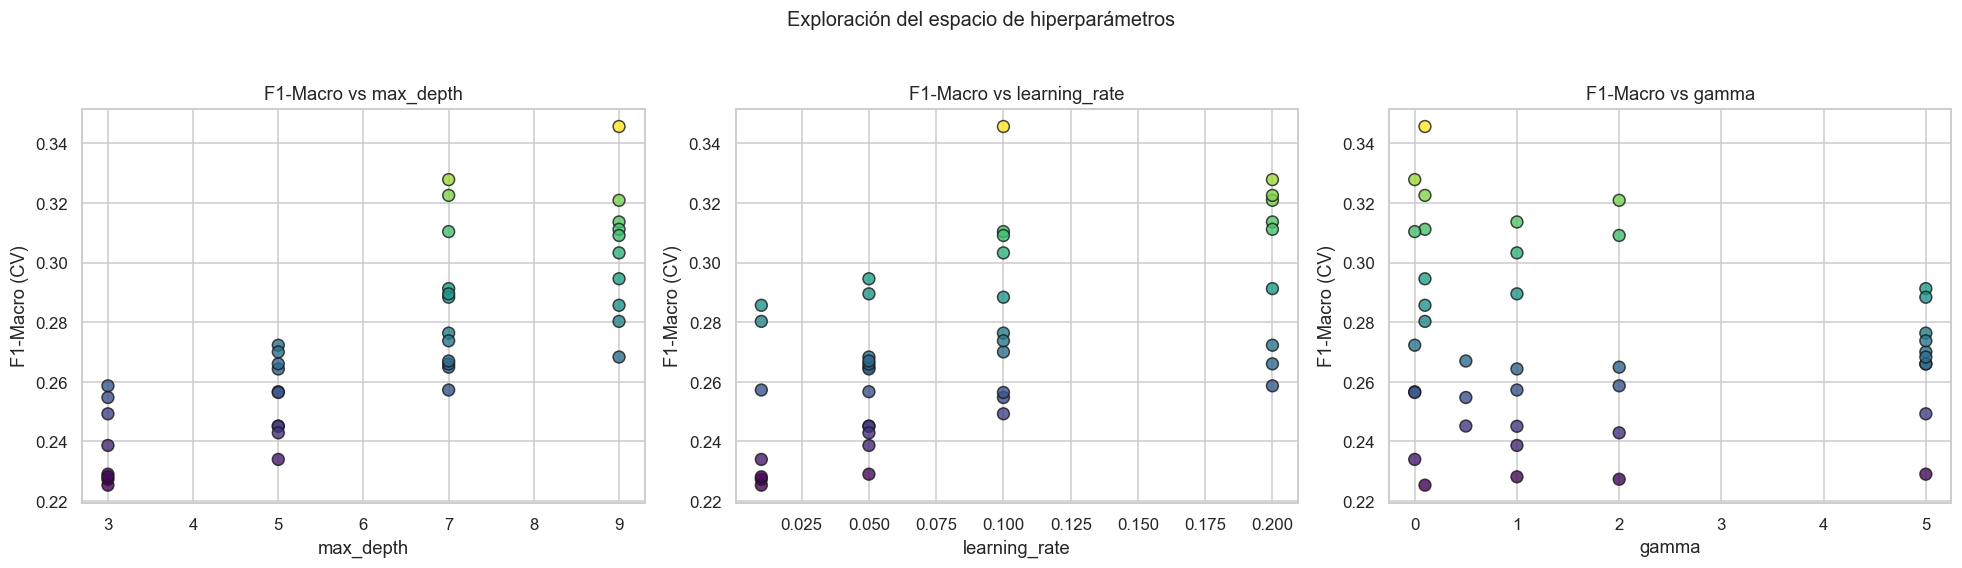

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, p in zip(axes, ['param_max_depth', 'param_learning_rate', 'param_gamma']):
    ax.scatter(cv_results[p].astype(float), cv_results['mean_test_score'],
               c=cv_results['mean_test_score'], cmap='viridis', s=60, edgecolor='k', alpha=0.8)
    ax.set_xlabel(p.replace('param_', '')); ax.set_ylabel('F1-Macro (CV)')
    ax.set_title(f'F1-Macro vs {p.replace("param_", "")}')
plt.suptitle('Exploración del espacio de hiperparámetros', y=1.03, fontsize=13)
plt.tight_layout(); plt.savefig('figuras/exp4_busqueda_hiperparams.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** La búsqueda conjunta da el **gran salto**: el mejor candidato alcanza **F1-macro 0.346 en CV**, frente a ~0.23 de los ajustes individuales. La configuración ganadora combina árboles **más profundos y numerosos** (`max_depth=9`, `n_estimators=300`) con regularización **suave pero presente** (`gamma=0.1`, `reg_lambda=0.01`, `reg_alpha=0.1`) y submuestreo (`subsample=0.7`, `colsample_bytree=0.8`). La moraleja: **lo que importa es la interacción entre capacidad del modelo y regularización, no cada palanca por separado.**

### Tabla comparativa de los 4 experimentos de regularización

Reunimos en una sola tabla el F1-macro de cada estrategia. La pregunta que responde: **¿basta con afinar un regularizador a la vez, o el verdadero salto viene de optimizarlos en conjunto** (junto con `max_depth`, `learning_rate`, etc.)**?**

In [18]:
resumen = pd.DataFrame({
    'Configuración': ['Baseline (defaults)',
                      f'Mejor gamma (g={best_gamma})',
                      f'Mejor lambda (l={best_lambda})',
                      f'Mejor alpha (a={best_alpha})',
                      'RandomizedSearchCV (conjunto)'],
    'F1-Macro': [f1_macro_base,
                 df_gamma['f1_macro'].max(),
                 df_lambda['f1_macro'].max(),
                 df_alpha['f1_macro'].max(),
                 random_search.best_score_],
})
resumen['F1-Macro'] = resumen['F1-Macro'].round(4)
print('=== Resumen comparativo de la regularización ===')
resumen

=== Resumen comparativo de la regularización ===


,Configuración,F1-Macro
0,Baseline (defaults),0.2356
1,Mejor gamma (g=0.1),0.2330
2,Mejor lambda (l=0.01),0.2346
3,Mejor alpha (a=0.01),0.2351
4,RandomizedSearchCV (conjunto),0.3457


> **¿Qué obtuvimos?** La tabla lo deja claro de un vistazo:

> | Estrategia | F1-Macro |
> |:--|:--:|
> | Baseline | 0.236 |
> | Mejor `gamma` solo | 0.233 |
> | Mejor `lambda` solo | 0.235 |
> | Mejor `alpha` solo | 0.235 |
> | **Búsqueda conjunta** | **0.346** |

> Los ajustes aislados **no superan** al baseline; el salto real (+0.11 de F1-macro, casi **+47 %** relativo) viene de **optimizar todos los hiperparámetros a la vez**. Con esta configuración construimos el modelo final.

## Fase 4 · Modelo final optimizado y evaluación completa

Entrenamos el modelo definitivo con los **mejores hiperparámetros** de la búsqueda. Combinamos
**train + validación** (2010–2022) para aprovechar más datos, y evaluamos **una sola vez** sobre el
**test (2023–2024)**, que no participó ni en el entrenamiento ni en la selección de hiperparámetros.
Esta es la estimación **honesta** del desempeño en producción.

In [19]:
best_params = random_search.best_params_.copy()
best_params.update(objective='multi:softprob', tree_method='hist', random_state=RANDOM_STATE)

X_tr_full = pd.concat([X_train, X_val]).reset_index(drop=True)
y_tr_full = pd.concat([y_train, y_val]).reset_index(drop=True)
sw_full = prep.get_sample_weights(y_tr_full)

xgb_final = xgb.XGBClassifier(**best_params)
xgb_final.fit(X_tr_full, y_tr_full, sample_weight=sw_full, verbose=False)
print('Modelo final entrenado con', len(X_tr_full), 'registros.')


Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163


Modelo final entrenado con 461566 registros.


### Batería completa de métricas sobre el test
Reportamos un conjunto amplio porque **ninguna métrica sola** describe bien un problema desbalanceado:

| Métrica | Qué mide | Por qué importa aquí |
|:--|:--|:--|
| **Accuracy** | % de aciertos global | Engañosa con desbalance (la clase mayoritaria la infla) |
| **Balanced Accuracy** | *Recall* promedio entre clases | Corrige el desbalance; trata las 5 clases por igual |
| **F1-Macro** | F1 promedio sin ponderar | Métrica guía: premia detectar clases raras |
| **F1-Weighted** | F1 ponderado por frecuencia | Refleja el desempeño "promedio del registro típico" |
| **Precision/Recall-Macro** | FP / FN promediados por clase | Diagnostica si el modelo es conservador o agresivo |
| **Log-Loss** | Calidad de las **probabilidades** | Penaliza la confianza mal calibrada |
| **Cohen's Kappa** | Acuerdo corregido por azar | Robusta al desbalance |
| **Kappa cuadrático** | Kappa que penaliza más los errores **lejanos** | Ideal para objetivo **ordinal**: confundir bajo↔crítico pesa más que bajo↔medio |
| **MCC** | Correlación de Matthews | Métrica balanceada incluso con clases muy desiguales |
| **AUC-ROC (OvR)** | Capacidad de *ranking* (1-vs-resto) | Independiente del umbral de decisión |
| **AUC-PR** | Área *precision-recall* | **Más informativa que ROC** cuando hay desbalance |

In [20]:
y_pred = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)
labels5 = list(range(5))
y_test_bin = label_binarize(y_test, classes=labels5)

print('=== Reporte de Clasificación · Modelo Final (Test 2023-2024) ===')
print(classification_report(y_test, y_pred, labels=labels5,
                            target_names=target_names, zero_division=0))

def metricas(yt, yp, pp, yt_bin):
    return {
        'Accuracy':              accuracy_score(yt, yp),
        'Balanced Accuracy':     balanced_accuracy_score(yt, yp),
        'F1-Macro':              f1_score(yt, yp, average='macro'),
        'F1-Weighted':           f1_score(yt, yp, average='weighted'),
        'Precision-Macro':       precision_score(yt, yp, average='macro', zero_division=0),
        'Recall-Macro':          recall_score(yt, yp, average='macro', zero_division=0),
        'Log Loss':              log_loss(yt, pp, labels=labels5),
        'Cohen Kappa':           cohen_kappa_score(yt, yp),
        'Kappa cuadrático':      cohen_kappa_score(yt, yp, weights='quadratic'),
        'MCC':                   matthews_corrcoef(yt, yp),
        'AUC-ROC (OvR macro)':   roc_auc_score(yt, pp, multi_class='ovr', average='macro', labels=labels5),
        'AUC-ROC (OvR weighted)':roc_auc_score(yt, pp, multi_class='ovr', average='weighted', labels=labels5),
        'AUC-PR (macro)':        average_precision_score(yt_bin, pp, average='macro'),
    }

metrics_final = metricas(y_test, y_pred, y_proba, y_test_bin)
print('\n=== Métricas del Modelo Final (Test) ===')
for k, v in metrics_final.items():
    print(f'  {k:24s}: {v:.4f}')

=== Reporte de Clasificación · Modelo Final (Test 2023-2024) ===
                 precision    recall  f1-score   support

  Sin siniestro       0.98      0.94      0.96     77242
    Riesgo bajo       0.05      0.23      0.08       526
   Riesgo medio       0.07      0.10      0.08      1096
    Riesgo alto       0.09      0.15      0.12       654
Pérdida crítica       0.15      0.14      0.15       742

       accuracy                           0.91     80260
      macro avg       0.27      0.31      0.28     80260
   weighted avg       0.94      0.91      0.93     80260




=== Métricas del Modelo Final (Test) ===
  Accuracy                : 0.9135
  Balanced Accuracy       : 0.3117
  F1-Macro                : 0.2776
  F1-Weighted             : 0.9271
  Precision-Macro         : 0.2696
  Recall-Macro            : 0.3117
  Log Loss                : 0.2828
  Cohen Kappa             : 0.1613
  Kappa cuadrático        : 0.2848
  MCC                     : 0.1694
  AUC-ROC (OvR macro)     : 0.8521
  AUC-ROC (OvR weighted)  : 0.8690
  AUC-PR (macro)          : 0.2414


> **¿Qué obtuvimos? (resultado central del notebook)** Sobre el **test imparcial 2023–2024** el modelo final logra:

> - **Accuracy 0.914** y **F1-weighted 0.927** — domina la clase mayoritaria casi perfecto (*Sin siniestro*: F1 0.96).
> - **F1-macro 0.278** y **balanced accuracy 0.312** — modesto, pero coherente: detectar siniestros raros con pocas variables (¡sin datos de clima!) es genuinamente difícil.
> - **AUC-ROC macro 0.852** — la señal más alentadora: aunque la *decisión dura* falle, el modelo **ordena bien** el riesgo (asigna mayor probabilidad a las siembras que sí se siniestran).
> - **Kappa cuadrático 0.285 > Kappa lineal 0.161** — como el cuadrático castiga más los errores "lejanos", que sea mayor confirma que **cuando el modelo se equivoca, suele hacerlo entre niveles vecinos**, respetando el orden del riesgo.

> En resumen: **un excelente detector de "todo en orden" y un *ranker* de riesgo razonable**, limitado en la decisión categórica fina de las clases minoritarias.

### Matriz de confusión final (absoluta y normalizada)
La versión **absoluta** muestra los conteos; la **normalizada por fila** muestra el *recall* por clase
(qué fracción de cada clase real se clasificó en cada categoría). La diagonal de la normalizada es
directamente la sensibilidad por nivel de riesgo.

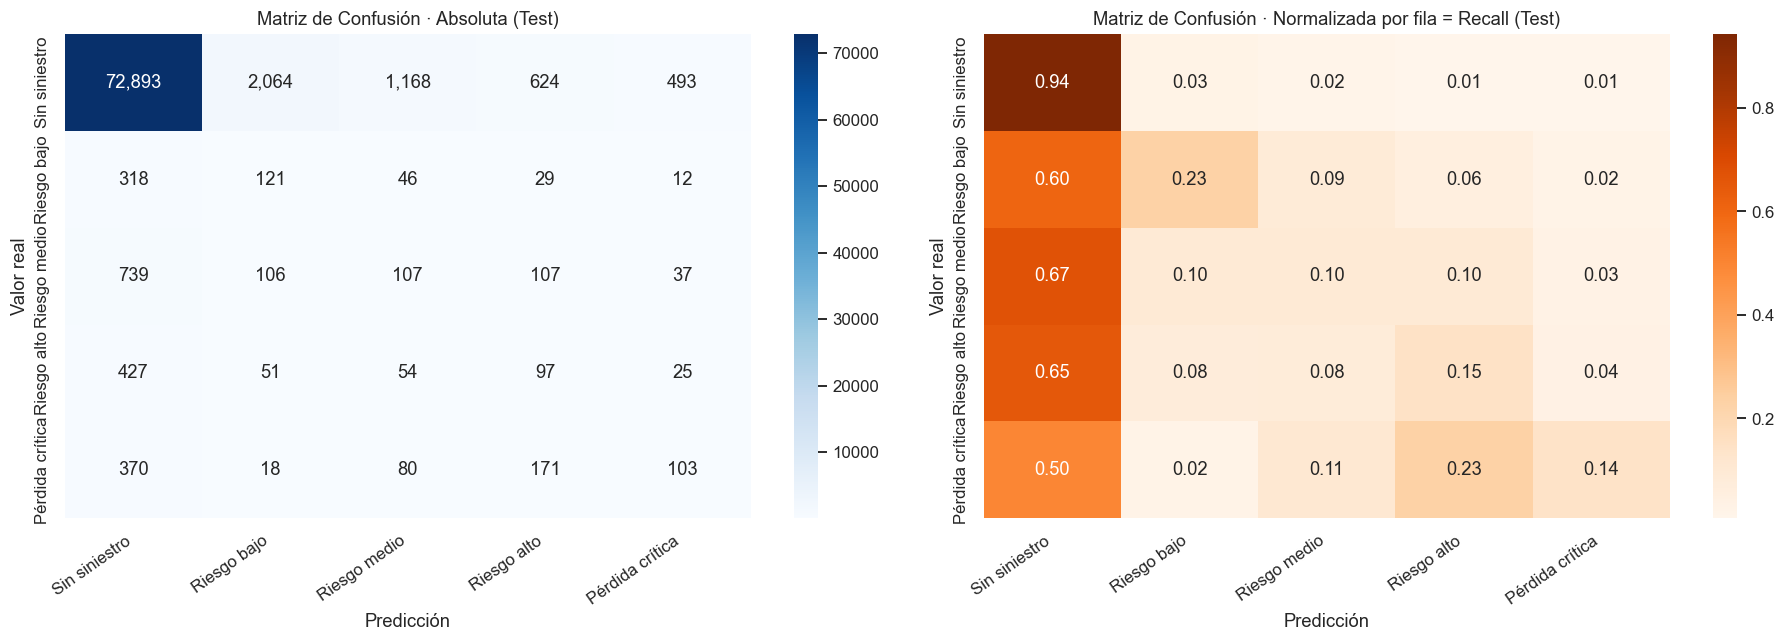

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=labels5)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Matriz de Confusión · Absoluta (Test)'); axes[0].set_ylabel('Valor real'); axes[0].set_xlabel('Predicción')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Matriz de Confusión · Normalizada por fila = Recall (Test)'); axes[1].set_ylabel('Valor real'); axes[1].set_xlabel('Predicción')
for ax in axes: ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.savefig('figuras/confusion_matrix_final.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** En la versión **normalizada por fila** (que es el *recall* por clase), la diagonal muestra que *Sin siniestro* se recupera casi perfecto, mientras que las clases de riesgo se reparten entre sí y hacia "Sin siniestro". Es la traducción visual del F1-macro bajo: el modelo ** subdetecta** los siniestros, no los inventa.

### Curvas ROC y Precision-Recall por clase (One-vs-Rest)
- **Curva ROC**: relaciona *recall* (TPR) contra la tasa de falsos positivos. El **AUC** ∈ [0,1]; 0.5 es azar, 1.0 es perfecto.
- **Curva Precision-Recall**: más adecuada bajo desbalance porque ignora los verdaderos negativos (la enorme clase "Sin siniestro"). El **AUC-PR** alto significa que el modelo mantiene buena precisión incluso al aumentar el *recall*.

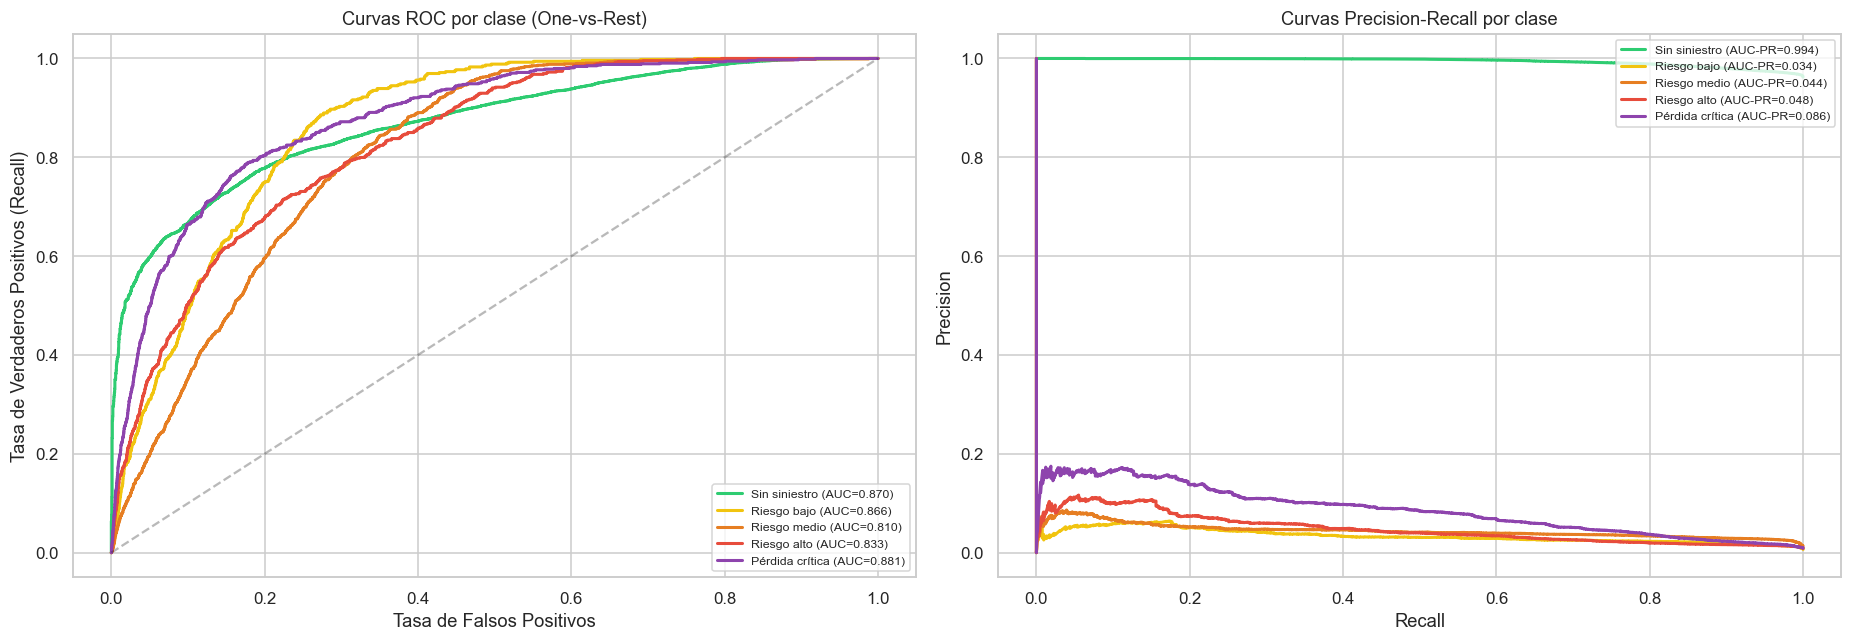

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for i in labels5:
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    axes[0].plot(fpr, tpr, color=PALETA_RIESGO[i], lw=2,
                 label=f'{target_names[i]} (AUC={auc(fpr, tpr):.3f})')
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    axes[1].plot(rec, prec, color=PALETA_RIESGO[i], lw=2,
                 label=f'{target_names[i]} (AUC-PR={auc(rec, prec):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('Curvas ROC por clase (One-vs-Rest)'); axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)'); axes[0].legend(loc='lower right', fontsize=8)
axes[1].set_title('Curvas Precision-Recall por clase'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.savefig('figuras/roc_pr_curves_final.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** Las curvas **ROC** quedan claramente por encima de la diagonal de azar (AUC macro 0.85): hay **capacidad de ranking real**. Las curvas **Precision-Recall**, más exigentes bajo desbalance, quedan bajas (AUC-PR macro 0.24) — el recordatorio de que, al fijar un umbral de decisión, mantener buena precisión en las clases raras sigue siendo el cuello de botella.

### Comparación *Baseline* vs. Modelo Optimizado (en test)

**¿Qué buscamos?** Poner lado a lado los dos modelos sobre el **mismo test imparcial (2023–2024)** y cuantificar, métrica por métrica, **cuánto ganamos** con todo el proceso de regularización y *tuning*. La columna Δ (mejora) hace explícito el avance —y también dónde hubo que ceder.

In [23]:
yb = xgb_baseline.predict(X_test); pb = xgb_baseline.predict_proba(X_test)
metrics_base = metricas(y_test, yb, pb, y_test_bin)

comp = pd.DataFrame({'Métrica': list(metrics_final.keys()),
                     'Baseline': list(metrics_base.values()),
                     'Optimizado': list(metrics_final.values())})
comp['Δ (mejora)'] = (comp['Optimizado'] - comp['Baseline']).round(4)
comp = comp.round(4)
print('=== Baseline vs. Optimizado (Test) ===')
comp

=== Baseline vs. Optimizado (Test) ===


,Métrica,Baseline,Optimizado,Δ (mejora)
0,Accuracy,0.8664,0.9135,0.0471
1,Balanced Accuracy,0.3356,0.3117,-0.0239
2,F1-Macro,0.2626,0.2776,0.0150
3,F1-Weighted,0.9029,0.9271,0.0242
4,Precision-Macro,0.2477,0.2696,0.0219
5,Recall-Macro,0.3356,0.3117,-0.0239
6,Log Loss,0.4423,0.2828,-0.1594
7,Cohen Kappa,0.1372,0.1613,0.0241
8,Kappa cuadrático,0.2429,0.2848,0.0419
9,MCC,0.1646,0.1694,0.0048


> **¿Qué obtuvimos?** La optimización mejora **casi todo**: *log-loss* se desploma de 0.442 a **0.283** (probabilidades mucho mejor calibradas), y suben accuracy (+0.047), F1-weighted (+0.024), Kappa cuadrático (+0.042) y los AUC. **La excepción** es la *balanced accuracy / recall-macro* (−0.024): el modelo optimizado es **más conservador** —lanza menos falsas alarmas, a costa de atrapar un poco menos las minoritarias—. Es un **intercambio deliberado** hacia un modelo más útil y confiable en conjunto.

#### Gráfica de radar comparativa
El **gráfico de radar** superpone varias métricas en un mismo eje polar: cuanto mayor el área cubierta,
mejor el modelo. Permite ver de un vistazo en qué dimensiones gana el modelo optimizado frente al baseline.

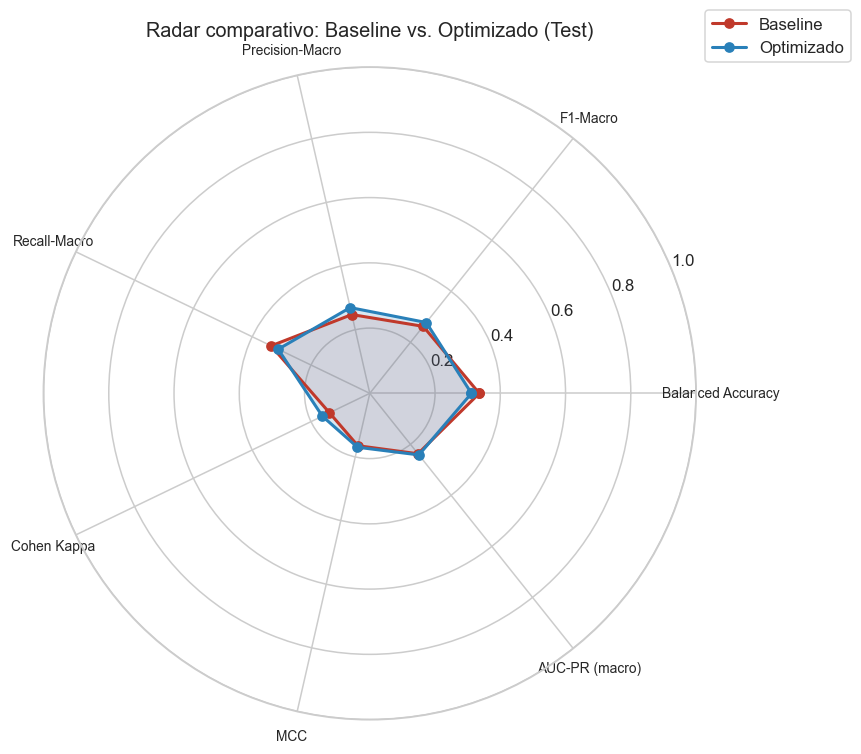

In [24]:
radar_m = ['Balanced Accuracy', 'F1-Macro', 'Precision-Macro', 'Recall-Macro',
           'Cohen Kappa', 'MCC', 'AUC-PR (macro)']
vals_b = [metrics_base[m] for m in radar_m]
vals_o = [metrics_final[m] for m in radar_m]
ang = np.linspace(0, 2*np.pi, len(radar_m), endpoint=False).tolist()
vals_b += vals_b[:1]; vals_o += vals_o[:1]; ang += ang[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(ang, vals_b, 'o-', lw=2, color='#c0392b', label='Baseline'); ax.fill(ang, vals_b, alpha=0.12, color='#c0392b')
ax.plot(ang, vals_o, 'o-', lw=2, color='#2980b9', label='Optimizado'); ax.fill(ang, vals_o, alpha=0.18, color='#2980b9')
ax.set_xticks(ang[:-1]); ax.set_xticklabels(radar_m, fontsize=9); ax.set_ylim(0, 1)
ax.set_title('Radar comparativo: Baseline vs. Optimizado (Test)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout(); plt.savefig('figuras/radar_comparacion.png', dpi=150, bbox_inches='tight'); plt.show()

## Fase 5 · Interpretabilidad del modelo

Un modelo preciso pero opaco es difícil de confiar. Aquí abrimos la "caja negra" con dos enfoques
complementarios: la **importancia nativa** de XGBoost y los **valores SHAP**.

### 5.1 · Importancia de variables (nativa de XGBoost)
XGBoost ofrece tres definiciones de importancia:
- **`weight`**: nº de veces que la variable se usa para partir un nodo.
- **`gain`**: ganancia promedio que aporta la variable al usarse (la más informativa).
- **`cover`**: nº promedio de muestras afectadas por sus *splits*.

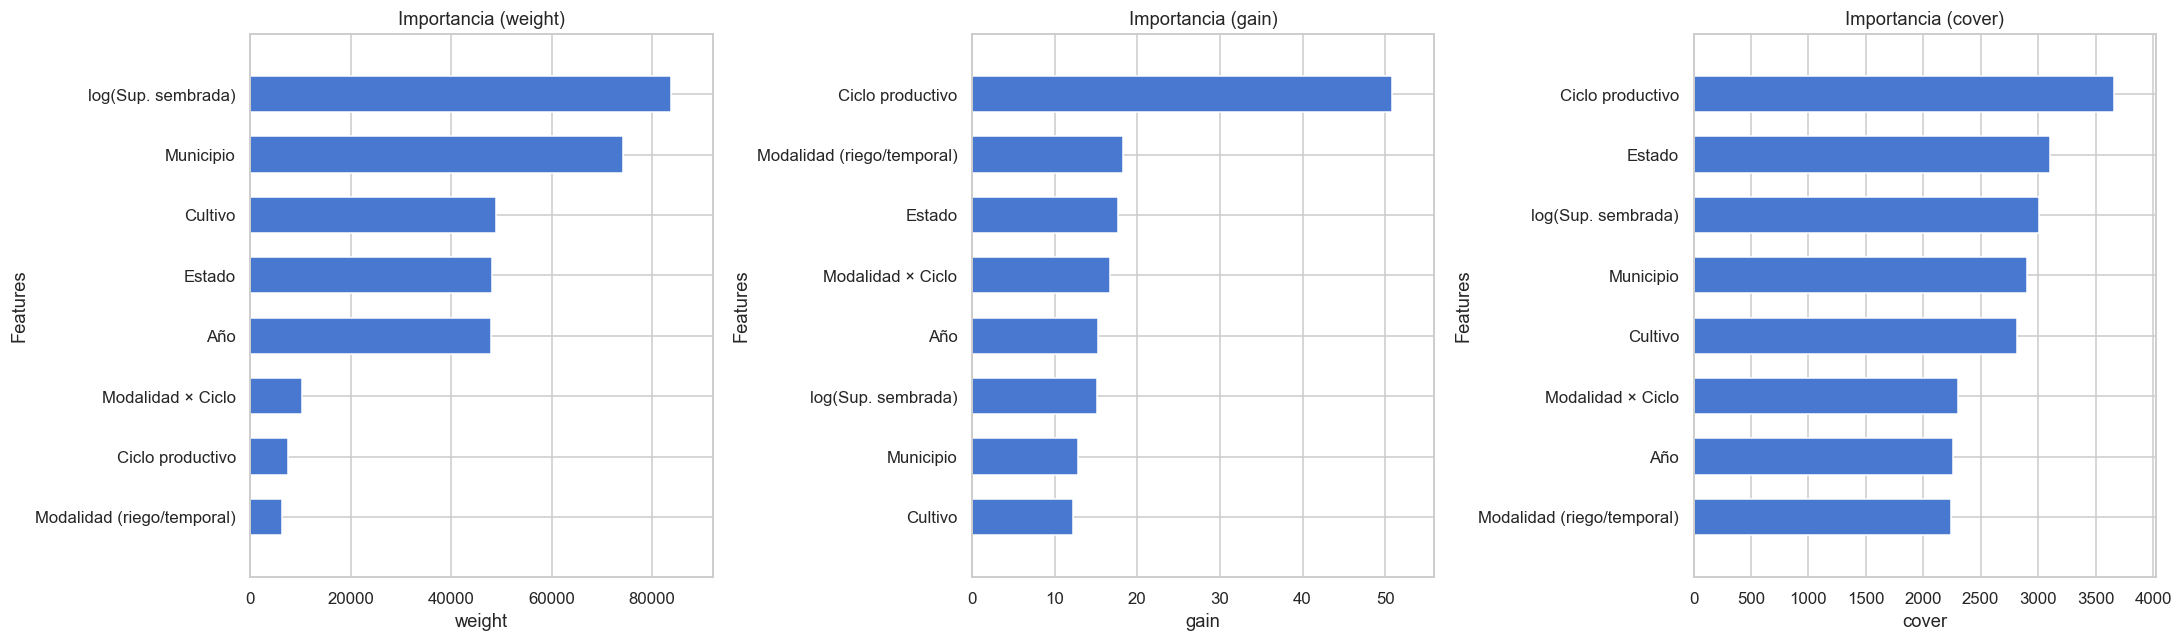

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, t in zip(axes, ['weight', 'gain', 'cover']):
    xgb.plot_importance(xgb_final, importance_type=t, ax=ax, title=f'Importancia ({t})',
                        xlabel=t, height=0.6, show_values=False)
plt.tight_layout(); plt.savefig('figuras/feature_importance_3metricas.png', dpi=150, bbox_inches='tight'); plt.show()

### 5.2 · Valores SHAP (SHapley Additive exPlanations)
SHAP descompone cada predicción en la **contribución** de cada variable, con base sólida en teoría de
juegos. A diferencia de la importancia nativa, nos dice **en qué dirección** empuja cada variable.

> *Nota técnica:* con `shap` ≥ 0.50 y XGBoost multiclase, `shap_values` es un **ndarray de forma
> `(n_muestras, n_features, n_clases)`**. Por eso seleccionamos cada clase con `shap_values[:, :, k]`
> (la API antigua de lista por clase ya no aplica).

In [26]:
import shap
explainer = shap.TreeExplainer(xgb_final)
n = min(3000, len(X_test))
X_sample = X_test.sample(n=n, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)   # ndarray (n, n_features, n_clases)
print('Forma de shap_values:', np.array(shap_values).shape, '-> (muestras, features, clases)')
shap_por_clase = [shap_values[:, :, k] for k in range(shap_values.shape[2])]

Forma de shap_values: (3000, 8, 5) -> (muestras, features, clases)


**Importancia media absoluta por clase** — qué variables pesan más para distinguir cada nivel de riesgo:

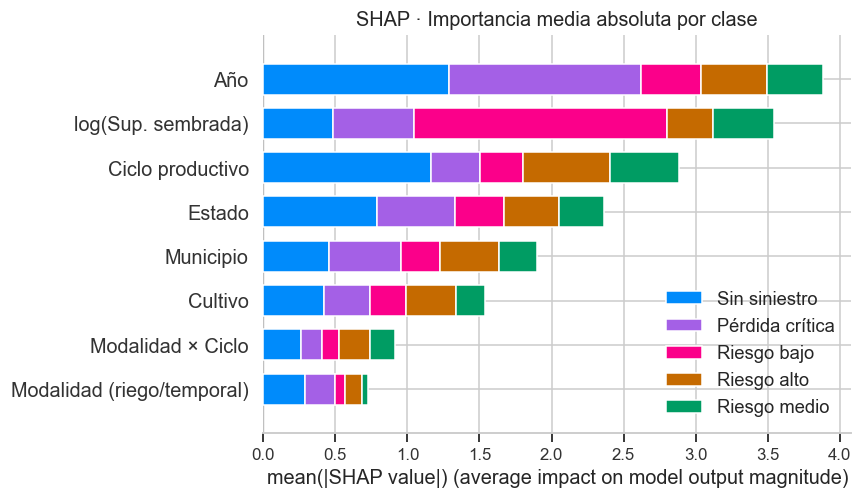

In [27]:
plt.figure()
shap.summary_plot(shap_por_clase, X_sample, plot_type='bar',
                  class_names=target_names, show=False)
plt.title('SHAP · Importancia media absoluta por clase', fontsize=13)
plt.tight_layout(); plt.savefig('figuras/shap_bar_summary.png', dpi=150, bbox_inches='tight'); plt.show()

**Beeswarm para "Pérdida crítica" (clase 4)** — la clase de mayor interés operativo. Cada punto es un
registro: su posición horizontal es el impacto SHAP (derecha = empuja hacia "pérdida crítica") y el color
es el valor de la variable (rojo alto, azul bajo).

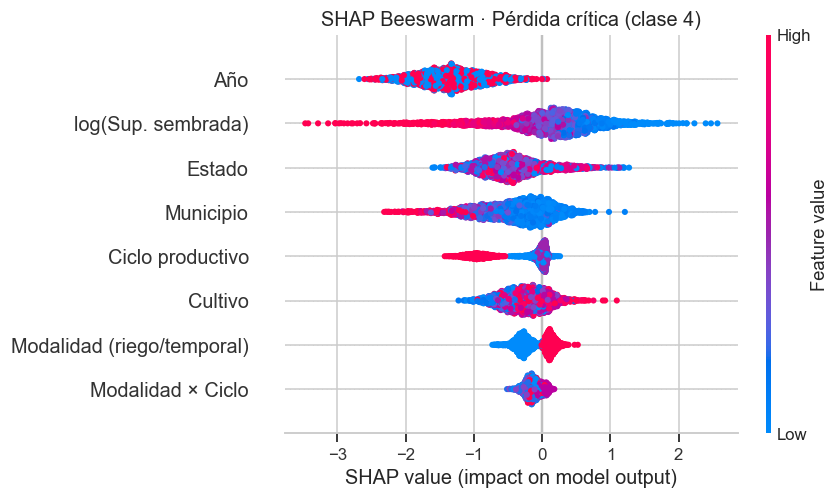

In [28]:
plt.figure()
shap.summary_plot(shap_values[:, :, 4], X_sample, show=False)
plt.title('SHAP Beeswarm · Pérdida crítica (clase 4)', fontsize=13)
plt.tight_layout(); plt.savefig('figuras/shap_beeswarm_perdida_critica.png', dpi=150, bbox_inches='tight'); plt.show()

**Dependence plots** de las 3 variables más influyentes para 'Pérdida crítica': muestran cómo cambia el impacto SHAP según el valor de la variable.

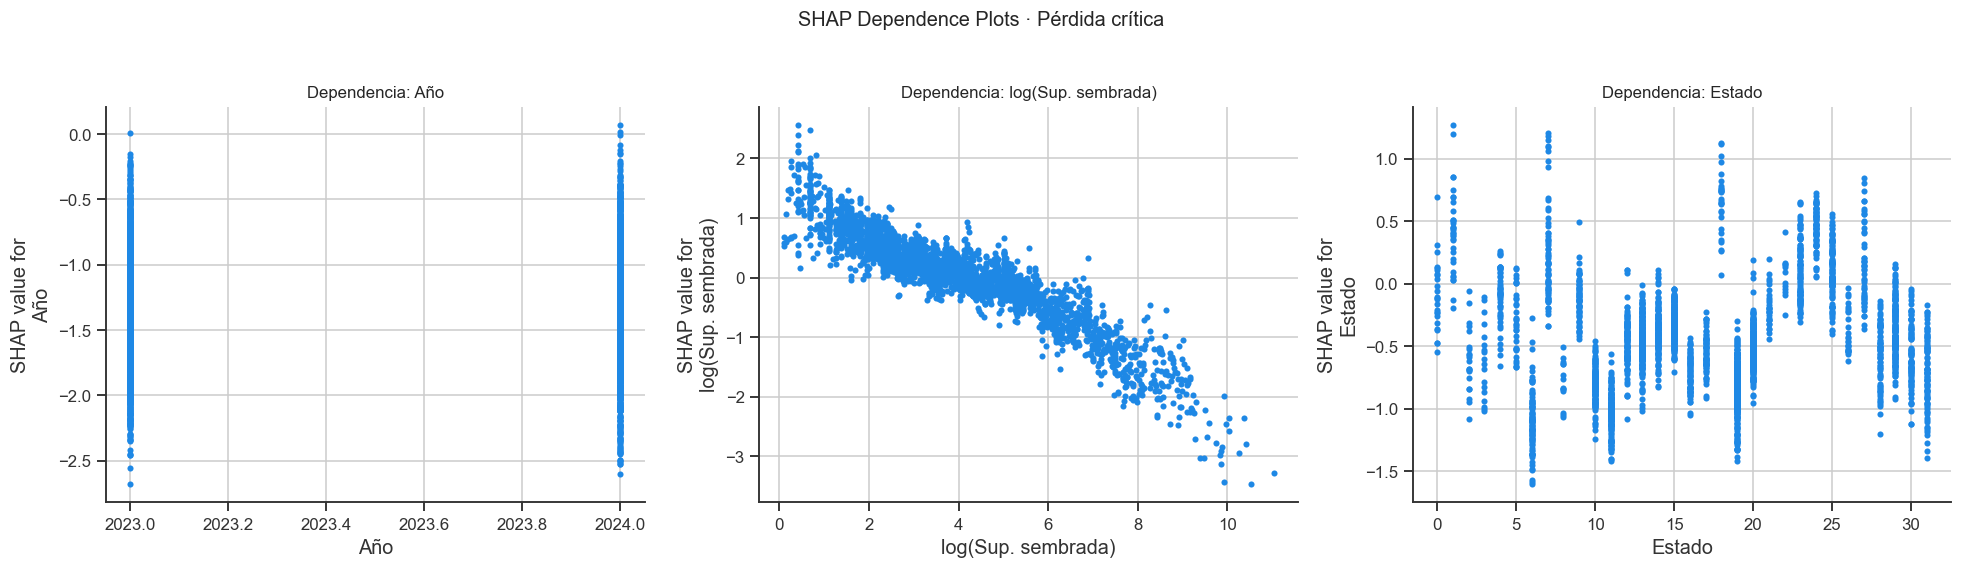

In [29]:
mean_abs = np.abs(shap_values[:, :, 4]).mean(axis=0)
top3 = [X_sample.columns[i] for i in np.argsort(mean_abs)[-3:][::-1]]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values[:, :, 4], X_sample, ax=ax,
                         interaction_index=None, show=False)
    ax.set_title(f'Dependencia: {feat}', fontsize=11)
plt.suptitle('SHAP Dependence Plots · Pérdida crítica', y=1.03, fontsize=13)
plt.tight_layout(); plt.savefig('figuras/shap_dependence_top3.png', dpi=150, bbox_inches='tight'); plt.show()

### 5.3 · Análisis de errores
Entender *dónde* falla el modelo es tan importante como su métrica global. Revisamos las confusiones más
frecuentes, el F1 por clase y dónde (geográficamente) se equivoca más.

In [30]:
err = y_pred != y_test.values
print(f'Errores totales: {err.sum():,} de {len(y_test):,} ({err.mean()*100:.2f}%)')
df_err = pd.DataFrame({'Real': pd.Series(y_test.values)[err].map(prep.riesgo_map_inv),
                       'Predicho': pd.Series(y_pred[err]).map(prep.riesgo_map_inv)})
conf = (df_err.groupby(['Real', 'Predicho']).size()
        .sort_values(ascending=False).head(10).reset_index(name='Frecuencia'))
print('\n=== Top 10 confusiones más frecuentes ===')
conf

Errores totales: 6,939 de 80,260 (8.65%)

=== Top 10 confusiones más frecuentes ===


,Real,Predicho,Frecuencia
0,Sin siniestro,Sin siniestro,120
1,Sin siniestro,Riesgo bajo,86
2,Pérdida crítica,Riesgo bajo,78
3,Pérdida crítica,Sin siniestro,67
4,Sin siniestro,Riesgo medio,46
5,Riesgo medio,Riesgo bajo,45
6,Riesgo alto,Riesgo bajo,43
7,Riesgo medio,Sin siniestro,42
8,Pérdida crítica,Riesgo medio,36
9,Sin siniestro,Riesgo alto,35


> **¿Qué obtuvimos?** La tasa de error global es **8.65 %**. Pero más importante que la cantidad es el **tipo**: las confusiones más costosas son *Pérdida crítica → Riesgo bajo* (78 casos) y *Pérdida crítica → Sin siniestro* (67 casos). Es decir, **los errores que más preocuparían en operación** —clasificar una pérdida casi total como riesgo leve o nulo— existen y deben señalarse como la principal limitación práctica del modelo actual.

**F1-score por nivel de riesgo** — revela qué clases domina el modelo y cuáles le cuestan (típicamente las minoritarias):

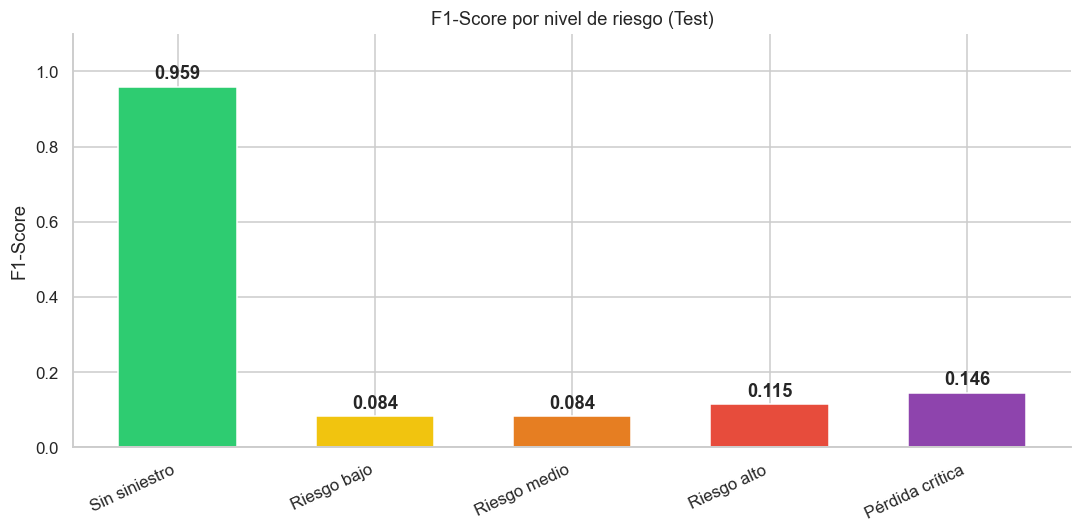

In [31]:
f1c = f1_score(y_test, y_pred, average=None, labels=labels5, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(target_names, f1c, color=PALETA_RIESGO, edgecolor='white', width=0.6)
for b, v in zip(bars, f1c):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('F1-Score por nivel de riesgo (Test)'); ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.1)
ax.spines[['top', 'right']].set_visible(False); plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.savefig('figuras/f1_por_clase.png', dpi=150, bbox_inches='tight'); plt.show()

**Probabilidad predicha de 'Pérdida crítica' vs. proporción real de siniestro.** Como el `nivel_riesgo`
se derivó de `proporcion_siniestro`, esta gráfica conecta la salida del clasificador con la variable
continua original: idealmente, a mayor proporción real de siniestro, mayor probabilidad asignada a la
clase crítica.

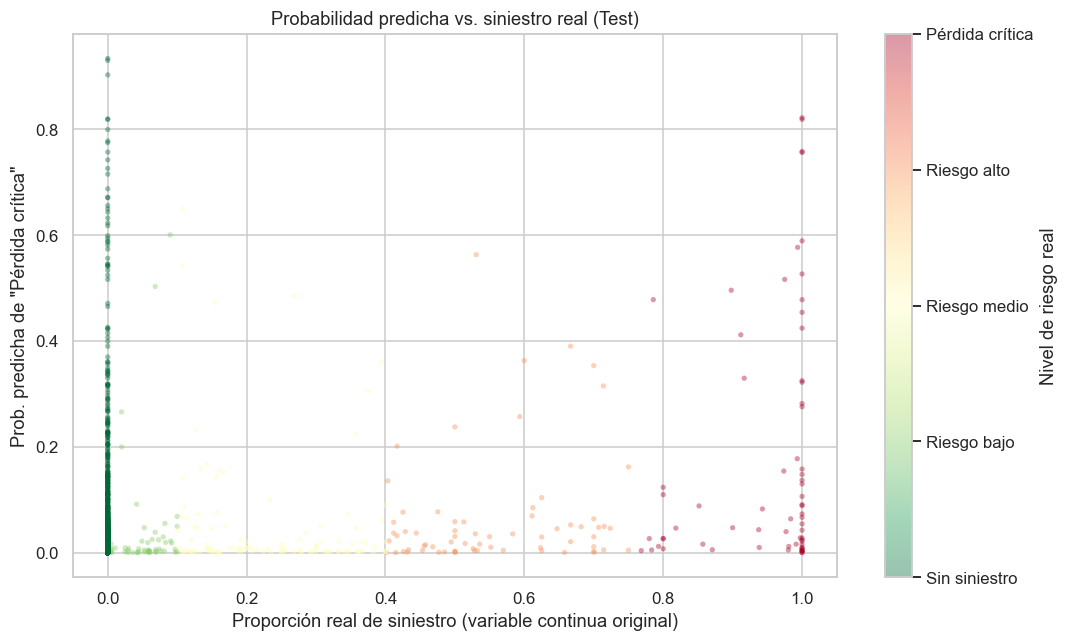

In [32]:
test_idx = X_test.index
prop_real = prep.df.loc[test_idx, 'proporcion_siniestro'].values
prob_critica = y_proba[:, 4]
m = np.random.RandomState(RANDOM_STATE).choice(len(prop_real), size=min(8000, len(prop_real)), replace=False)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(prop_real[m], prob_critica[m], c=y_test.values[m], cmap='RdYlGn_r',
                alpha=0.4, s=12, edgecolor='none')
ax.set_xlabel('Proporción real de siniestro (variable continua original)')
ax.set_ylabel('Prob. predicha de "Pérdida crítica"')
ax.set_title('Probabilidad predicha vs. siniestro real (Test)')
cb = plt.colorbar(sc, ax=ax, ticks=labels5); cb.set_label('Nivel de riesgo real'); cb.set_ticklabels(target_names)
plt.tight_layout(); plt.savefig('figuras/scatter_prob_vs_real.png', dpi=150, bbox_inches='tight'); plt.show()

**Tasa de error por estado (top 12 por volumen)** — ¿hay regiones donde el modelo es menos confiable?

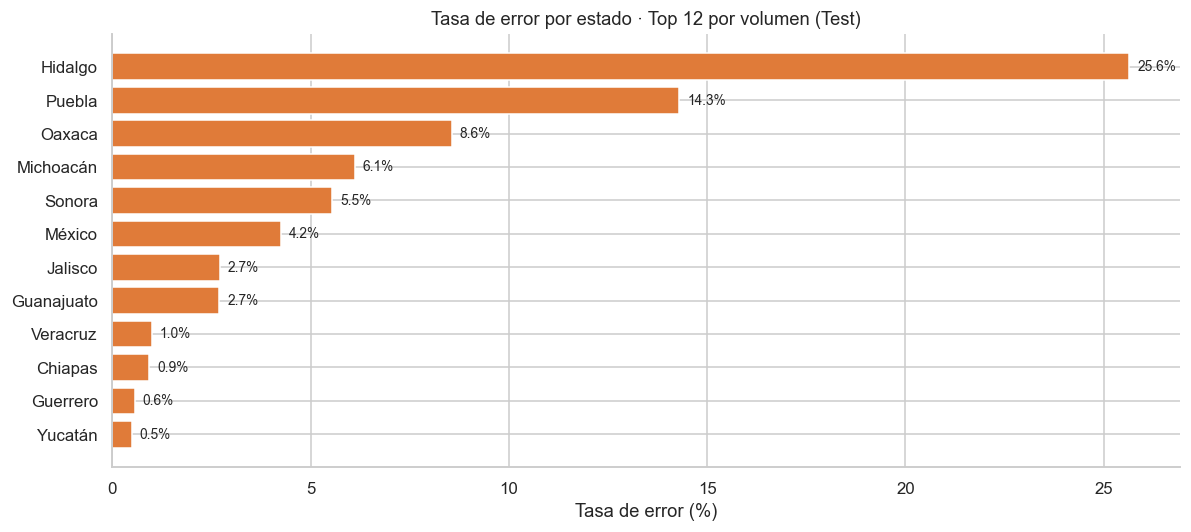

In [33]:
est = prep.df.loc[test_idx, 'Nomestado'].values
de = pd.DataFrame({'estado': est, 'error': err.astype(int)})
top_estados = de['estado'].value_counts().head(12).index
tasa = (de[de['estado'].isin(top_estados)].groupby('estado')['error']
        .mean().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(tasa.index[::-1], tasa.values[::-1]*100, color='#e07b39', edgecolor='white')
ax.set_xlabel('Tasa de error (%)'); ax.set_title('Tasa de error por estado · Top 12 por volumen (Test)')
for b, v in zip(bars, tasa.values[::-1]*100):
    ax.text(v+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/error_por_estado.png', dpi=150, bbox_inches='tight'); plt.show()

## Fase 6 · Validación cruzada y robustez

La evaluación temporal da **una** foto. Para confirmar que el desempeño es **estable** (y no fruto de un
*split* afortunado), repetimos la evaluación con **validación cruzada estratificada de 5 *folds*** sobre
los datos de desarrollo (train + val). No incluimos el test para no contaminar la evaluación final.

> *Nota técnica:* `cross_validate` ya no acepta `fit_params`; pasamos `sample_weight` mediante `params=`
> gracias al enrutamiento de metadatos activado en la Fase 0.

In [34]:
X_dev = pd.concat([X_train, X_val]).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val]).reset_index(drop=True)
sw_dev = prep.get_sample_weights(y_dev).to_numpy()

xgb_cv = xgb.XGBClassifier(**best_params)
xgb_cv.set_fit_request(sample_weight=True)

scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy',
           'roc_auc_ovr': 'roc_auc_ovr', 'neg_log_loss': 'neg_log_loss'}

print('Ejecutando 5-Fold Stratified Cross-Validation...')
cvres = cross_validate(xgb_cv, X_dev, y_dev,
                       cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                       scoring=scoring, params={'sample_weight': sw_dev},
                       return_train_score=True, n_jobs=-1)
print('\n=== Resultados Cross-Validation (5-Fold) ===')
for mname in scoring:
    te, tr = cvres[f'test_{mname}'], cvres[f'train_{mname}']
    print(f'  {mname:14s} | Test: {te.mean():.4f} ± {te.std():.4f}  |  Train: {tr.mean():.4f} ± {tr.std():.4f}')


Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163
Ejecutando 5-Fold Stratified Cross-Validation...



=== Resultados Cross-Validation (5-Fold) ===
  f1_macro       | Test: 0.3410 ± 0.0015  |  Train: 0.5178 ± 0.0009
  accuracy       | Test: 0.8280 ± 0.0007  |  Train: 0.8586 ± 0.0007
  roc_auc_ovr    | Test: 0.9155 ± 0.0005  |  Train: 0.9898 ± 0.0001
  neg_log_loss   | Test: -0.4801 ± 0.0025  |  Train: -0.4195 ± 0.0014


> **¿Qué obtuvimos?** El F1-macro en los 5 *folds* es **0.341 ± 0.0015**: una desviación minúscula significa que el resultado es **muy estable y no fruto de un *split* afortunado**. El AUC-ROC se mantiene alto (0.916). Eso sí, el F1-macro de *train* (0.518) supera notablemente al de *test* (0.341): hay **sobreajuste residual**, que examinamos en la curva de aprendizaje.

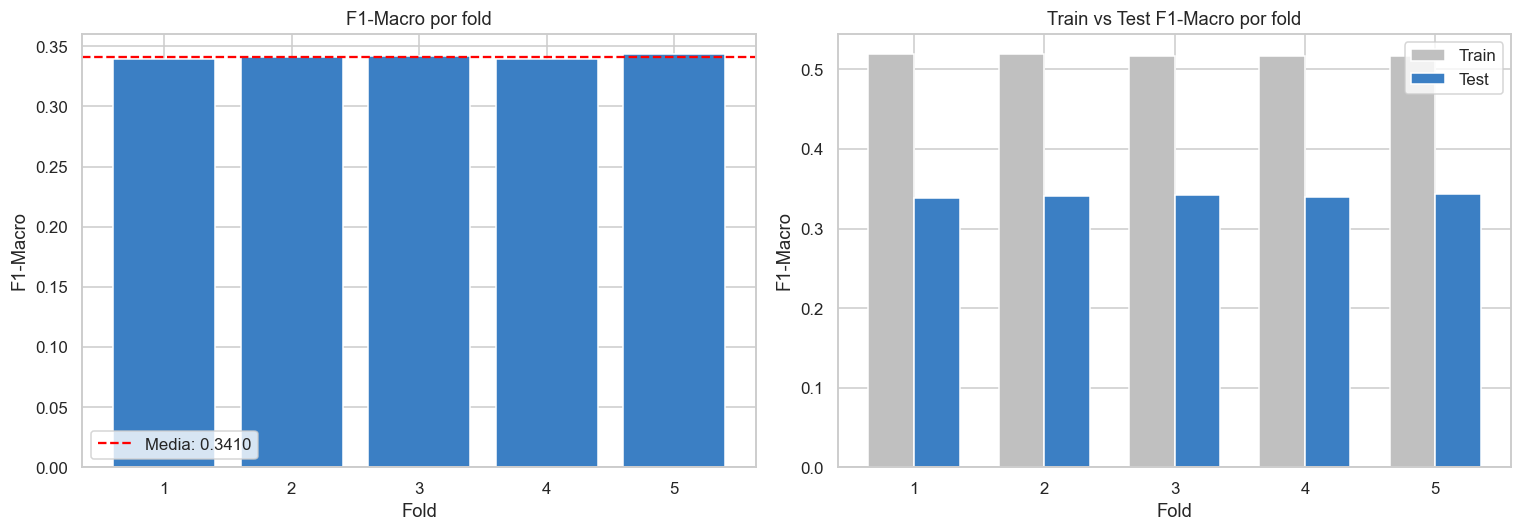

In [35]:
folds = np.arange(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(folds, cvres['test_f1_macro'], color='#3b7fc4', edgecolor='white')
axes[0].axhline(cvres['test_f1_macro'].mean(), color='red', ls='--',
                label=f"Media: {cvres['test_f1_macro'].mean():.4f}")
axes[0].set_title('F1-Macro por fold'); axes[0].set_xlabel('Fold'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
w = 0.35
axes[1].bar(folds-w/2, cvres['train_f1_macro'], w, label='Train', color='#c0c0c0', edgecolor='white')
axes[1].bar(folds+w/2, cvres['test_f1_macro'], w, label='Test', color='#3b7fc4', edgecolor='white')
axes[1].set_title('Train vs Test F1-Macro por fold'); axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-Macro'); axes[1].legend()
plt.tight_layout(); plt.savefig('figuras/cross_validation_folds.png', dpi=150, bbox_inches='tight'); plt.show()

### Curva de aprendizaje
¿El modelo se beneficiaría de **más datos** o ya tocó techo? La curva de aprendizaje entrena con
fracciones crecientes del conjunto y compara el desempeño en train vs validación:
- Si ambas curvas convergen alto → el modelo aprovecha bien los datos.
- Si hay una **brecha** grande train-validación → sobreajuste.
- Si la curva de validación sigue subiendo → más datos ayudarían.

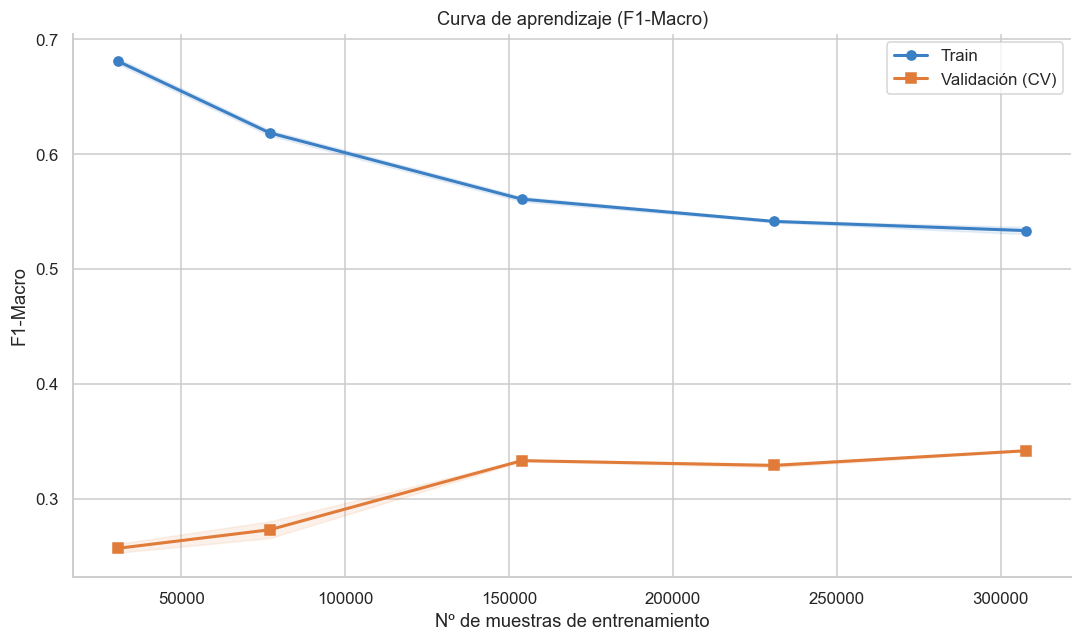

Brecha Train-Validación final: 0.1918
-> Hay sobreajuste; convendría más regularización.


In [36]:
xgb_lc = xgb.XGBClassifier(**best_params)
xgb_lc.set_fit_request(sample_weight=True)
sizes, tr_sc, te_sc = learning_curve(
    xgb_lc, X_dev, y_dev, train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', params={'sample_weight': sw_dev}, n_jobs=-1)

trm, trs = tr_sc.mean(1), tr_sc.std(1)
tem, tes = te_sc.mean(1), te_sc.std(1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(sizes, trm-trs, trm+trs, alpha=0.1, color='#3b7fc4')
ax.fill_between(sizes, tem-tes, tem+tes, alpha=0.1, color='#e07b39')
ax.plot(sizes, trm, 'o-', color='#3b7fc4', lw=2, label='Train')
ax.plot(sizes, tem, 's-', color='#e07b39', lw=2, label='Validación (CV)')
ax.set_title('Curva de aprendizaje (F1-Macro)'); ax.set_xlabel('Nº de muestras de entrenamiento'); ax.set_ylabel('F1-Macro'); ax.legend(loc='best')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/learning_curve.png', dpi=150, bbox_inches='tight'); plt.show()

gap = trm[-1] - tem[-1]
print(f'Brecha Train-Validación final: {gap:.4f}')
if gap > 0.05:
    print('-> Hay sobreajuste; convendría más regularización.')
elif tem[-1] - tem[-2] > 0.005:
    print('-> El modelo aún mejora con más datos.')
else:
    print('-> El modelo convergió; más datos no mejorarían significativamente.')

> **¿Qué obtuvimos?** La brecha final train–validación es **0.192**: confirma el sobreajuste que insinuaba la CV. Las curvas no han colapsado una sobre otra, lo que sugiere que **más datos —y sobre todo, mejores variables (clima)— probablemente ayudarían** más que seguir apretando la regularización. Esto enlaza directo con las limitaciones de las conclusiones.

## Conclusiones, fortalezas y limitaciones

**Lo que funcionó**
- El *split* temporal + `sample_weight` permite entrenar con datos históricos y evaluar honestamente sobre el futuro sin alterar la distribución real.
- La regularización (`gamma`, `lambda`, `alpha`) controla el sobreajuste; la búsqueda conjunta encuentra el mejor balance sesgo-varianza.
- SHAP e importancia nativa coinciden en señalar las variables determinantes del riesgo, lo que da confianza interpretativa.

**Limitaciones**
- Solo se usan variables del SIAP; **faltan datos climáticos** (precipitación, temperatura, sequía) que probablemente son los mayores predictores del siniestro.
- El *Label Encoding* impone un orden artificial a cultivos/municipios; *Target Encoding* o *embeddings* lo mejorarían.
- El desbalance extremo limita el *recall* de las clases minoritarias pese a los pesos.

**Trabajo futuro**
- Integrar datos meteorológicos del SMN.
- Probar *Target Encoding* y comparar con LightGBM / CatBoost.
- Complementar con un enfoque de **regresión** sobre `proporcion_siniestro`.